In [10]:
## config
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("healthcare.duckdb")

con.execute("PRAGMA threads=8")
con.execute("SET memory_limit='6GB'")

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)

Noto Sans CJK JP


### preset data and subtasks
1. create new table of atc4_sick + atc2 master
    - data likage ! : cmpn > atc4 > atc3 > mefi
2. create growth feature table
3. create growth-classified tables 
    - market position by atc2
    - sensitivity check
    - base effect check (only after visualization)


In [ ]:
con.execute("""
CREATE OR REPLACE VIEW mefi_sick AS
SELECT * exclude(totUseQty,msupUseAmt) ,
msupUseAmt as totUseQty,
totUseQty as msupUseAmt,
FROM read_parquet(
    'parquet/mefi_sick/*.parquet',
    union_by_name = true
);
""")

con.execute("""
CREATE OR REPLACE VIEW atc234_sick AS

SELECT
    a.col_1::VARCHAR AS diagYm,
    b.atcStep1Cd,
    b.atcStep1CdNm,
    left(a.col_3, 3)::VARCHAR AS atcStep2Cd,
    b.atcStep2CdNm,
    left(a.col_3, 4)::VARCHAR AS atcStep3Cd,
    a.col_3::VARCHAR AS atcStep4Cd,
    a.col_8::VARCHAR AS atcStep4CdNm,
    a.col_4::VARCHAR AS insupTpCd,
    TRY_CAST(a.col_5 AS DOUBLE) AS totUseQty,
    TRY_CAST(a.col_6 AS DOUBLE) AS msupUseAmt,
    a.col_7::VARCHAR AS st3SickSym,
    a.col_2::VARCHAR AS st3SickSymNm
FROM read_parquet(
    'parquet/atc4_sick/*.parquet',
    union_by_name = true
) AS a
LEFT JOIN read_csv('raw_data/atc2_master.csv') AS b
    ON left(a.col_3, 3) = b.atcStep2Cd;;
""")

In [27]:
con.execute("select * from atc234_sick where atcStep2CdNm is null limit 1").df()

,diagYm,atcStep1Cd,atcStep1CdNm,atcStep2Cd,atcStep2CdNm,atcStep3Cd,atcStep4Cd,atcStep4CdNm,insupTpCd,totUseQty,msupUseAmt,st3SickSym,st3SickSymNm


In [16]:
con.execute("""
CREATE OR REPLACE VIEW atc4_sick AS

SELECT
    col_1::VARCHAR AS diagYm,
    col_2::VARCHAR AS st3SickSymNm,
    col_3::VARCHAR AS atcStep4Cd,
    col_4::VARCHAR AS insupTpCd,
    TRY_CAST(col_5 AS DOUBLE) AS totUseQty,
    TRY_CAST(col_6 AS DOUBLE) AS msupUseAmt,
    col_7::VARCHAR AS st3SickSym,
    col_8::VARCHAR AS atcStep4CdNm

FROM read_parquet(
    'parquet/atc4_sick/*.parquet',
    union_by_name = true
);

CREATE OR REPLACE VIEW cmpn_sick AS

SELECT
    col_1::VARCHAR AS diagYm,
    col_2::VARCHAR AS st3SickSymNm,
    col_3::VARCHAR AS gnlNmCd,
    col_4::VARCHAR AS gnlNmCdNm,
    col_5::VARCHAR AS insupTpCd,
    TRY_CAST(col_6 AS DOUBLE) AS totUseQty,
    TRY_CAST(col_7 AS DOUBLE) AS msupUseAmt,
    col_8::VARCHAR AS st3SickSym

FROM read_parquet(
    'parquet/cmpn_sick/*.parquet',
    union_by_name = true
);""")

In [17]:
con.execute("select  * from cmpn_sick limit 1;").df()

,diagYm,st3SickSymNm,gnlNmCd,gnlNmCdNm,insupTpCd,totUseQty,msupUseAmt,st3SickSym
0,202001,1형 당뇨병,100701ACH,acebrophylline,4,216.0,44676.0,AE10


In [26]:
con.execute("""
CREATE OR REPLACE VIEW cmpn_atc_sick AS
SELECT
    a.*,
    b.AtcCd, b.AtcCdNm, b.MFDScd, b.ProdCd
FROM cmpn_sick AS a
LEFT JOIN read_csv('raw_data/prod_atc_map_20250630.csv') AS b
    ON gnlNmCd = b.MainCmpnCd;;
""")
con.execute("select * from cmpn_atc_sick limit 1").df()

,diagYm,st3SickSymNm,gnlNmCd,gnlNmCdNm,insupTpCd,totUseQty,msupUseAmt,st3SickSym,AtcCd,AtcCdNm,MFDScd,ProdCd
0,202001,다리의 상세불명 부위의 기타 손상,228708BIJ,sodium chloride(0.9%),5,15.0,4672.0,AT13,B05XA03,sodium chloride,331,644902691


In [29]:
con.execute("select count(*) from cmpn_atc_sick where AtcCd is null limit 1").df()

,count_star()
0,831252


### visualize
- overall (mefi)
    - onset : size 
    - period : cgr, cagr
- composition (mefi)
    - onset : composition ratio
    - period : cgr(include: negative case)
        - market position by cgr & cag
        - ratio gain
- internal composition (atc3,atc4)
    - period : atc2 -> atc3 -> atc4

In [13]:
# totla marker size and growth
market_year = con.execute("""
WITH yearly AS (
    SELECT
        LEFT(CAST(diagYm AS VARCHAR), 4) AS year,
        SUM(msupUseAmt) AS market_amt,
        SUM(totUseQty) AS market_qty
    FROM mefi_sick
    GROUP BY 1
)
SELECT
    year,
    market_amt,
    market_qty,
FROM yearly
ORDER BY year
""").fetchdf()

market_year["amt_cgr"] = (
    market_year["market_amt"].pct_change() * 100
)

market_year["qty_cgr"] = (
    market_year["market_qty"].pct_change() * 100
)

market_year

,year,market_amt,market_qty,amt_cgr,qty_cgr
0,2020,3.784598e+13,8.208685e+10,NaN,NaN
1,2021,4.125671e+13,8.723620e+10,9.012127,6.273044
2,2022,4.215731e+13,9.853967e+10,2.182913,12.957315


In [14]:
# growth rate
y1 = market_year.iloc[0]
y3 = market_year.iloc[-1]

market_summary = pd.DataFrame({
    "metric": ["msupUseAmt", "totUseQty"],
    "Y1": [y1["market_amt"], y1["market_qty"]],
    "Y3": [y3["market_amt"], y3["market_qty"]],
    "growth": [
        y3["market_amt"] - y1["market_amt"],
        y3["market_qty"] - y1["market_qty"]
    ],
    "cgr": [
        (y3["market_amt"] / y1["market_amt"] - 1) * 100,
        (y3["market_qty"] / y1["market_qty"] - 1) * 100
    ]
})

import numpy as np
market_summary['cagr'] = np.sqrt(market_summary.cgr.abs())
market_summary

,metric,Y1,Y3,growth,cgr,cagr
0,msupUseAmt,3.784598e+13,4.215731e+13,4.311326e+12,11.391768,3.375169
1,totUseQty,8.208685e+10,9.853967e+10,1.645281e+10,20.043177,4.476961


findfont: Failed to find font weight bold for Noto Sans CJK JP, now using 400.
findfont: Failed to find font weight bold for Noto Sans CJK JP, now using 400.
findfont: Failed to find font weight bold for Noto Sans CJK JP, now using 400.


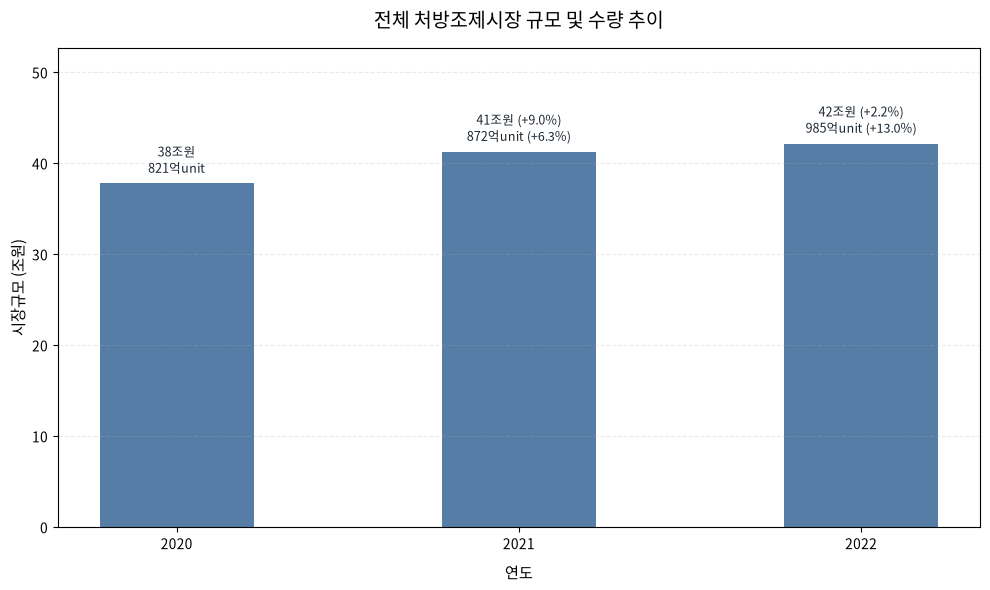

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

# 1. Canvas 및 Axis 생성 (반드시 실행되어야 함)
fig, ax = plt.subplots(figsize=(10, 6))

# 금액 조 단위 변환
y_values = market_year["market_amt"] / 1e12

# 2. 막대 그래프 생성
bars = ax.bar(
    market_year["year"], 
    y_values, 
    color='#2b5c8f', 
    alpha=0.8, 
    width=0.45
)

ax.set_xlabel('연도', fontsize=11, labelpad=10)
ax.set_ylabel('시장규모 (조원)', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Y축 상단 여유 공간 확보 (NaN 방지)
max_val = np.nanmax(y_values) if not np.isnan(np.nanmax(y_values)) else 100
ax.set_ylim(0, max_val * 1.25)

# 3. 막대 상단 2줄 레이블 표기 (금액 + 수량)
for bar, amt_pct, qty, qty_pct in zip(
    bars, 
    market_year["amt_cgr"], 
    market_year["market_qty"]/1e8,  # 수량은 1e8로 나누지 않음
    market_year["qty_cgr"]
):
    height = bar.get_height()
    
    # 1번째 줄: 금액 및 금액 성장률
    if pd.isna(amt_pct):
        amt_text = f'{height:,.0f}조원'
    else:
        amt_text = f'{height:,.0f}조원 ({amt_pct:+.1f}%)'
        
    # 2번째 줄: 수량 및 수량 성장률
    if pd.isna(qty_pct):
        qty_text = f'{qty:,.0f}억unit'
    else:
        qty_text = f'{qty:,.0f}억unit ({qty_pct:+.1f}%)'
    
    # 줄바꿈(\n)으로 병합
    full_text = f'{amt_text}\n{qty_text}'
    
    ax.annotate(
        full_text,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center', va='bottom', 
        fontsize=9, fontweight='bold', color='#1a252f',
        linespacing=1.3
    )

plt.title("전체 처방조제시장 규모 및 수량 추이", fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(market_year["year"])
ax.grid(True, axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

## 약효군 섹터 분할후 Market Diagnosis

* Largest: 이미 큰 성숙 섹터

* Rapid: 작은 기저에서 급성장한 섹터

* Consistent: 매년 안정적으로 증가한 섹터

### Sector Design

| 성장 유형 | 시장분석 의미 |
| :--- | :--- | 
| **Large + Consistent** | 매년 증가하는 구조적 성장 시장 |
| **Large + Declining** | 규모는 크지만 축소되는 시장 또는 대체·전환 가능성이 있는 시장 |
| **Non-consistent growth** | 특정 연도에 급증·급감한 변동성 시장 |
| **Other / Flat** | 정체시장 또는 감소 패턴이 뚜렷하지 않은 시장 |


### Condition
* Largest/smallest : Y3 

* Consistent growth: Y1 < Y2 < Y3

* Declining: Y1 > Y2 > Y3

* Non-consistent growth: Y3 > Y1이지만 중간 연도에 감소가 있음

* Other / Flat: Y3 ≤ Y1이면서 명확한 감소 추세가 아닌 경우

### Interpret Market 

* Largest∩Consistent가 많고 Rapid∩Consistent가 적다면: 성숙한 반복 조제시장 중심

* Rapid∩Consistent가 많고 Largest∩Consistent가 적다면: 아직 규모는 작지만 지속적으로 커지는 성장시장 중심

### Interpret Market sector 
| 후보 유형 | 바로팜 | 동네약국 | 제약회사 |
| :--- | :--- | :--- | :--- |
| **Large + Consistent** | 재고·수요예측 | 반복 조제 | 기존 시장 방어 |
| **Small + Rapid + Consistent** | 성장 카테고리 탐색 | 신규 수요 관찰 | 신규 시장 검토 |
| **Large + Rapid + Non-consistent** | 급증·공급 리스크 | 재고 변동 대응 | 성장 원인 검증 |
| **Large + Declining** | 재고 최적화 | 대체 처방 관찰 | 포트폴리오 재검토 |

### largest, rapid ,condsistent sector의 교집합 =0 (top 10)으로 인한 민감도 분석
* Largest: Y3 시장규모 amt_y3

* Rapid: Y1→Y3 누적성장률 amt_growth_rate (not CAGR)

* Consistent(amt기준): Y1 < Y2 < Y3인 약효분류군 중 성장률 순위

* 비교 대상: Top 10, 15, 20, 30

In [35]:
con.execute("""
CREATE OR REPLACE VIEW growth_base AS

WITH available_years AS (
    SELECT 
        CAST(LEFT(CAST(diagYm AS VARCHAR), 4) AS INTEGER) AS year
    FROM mefi_sick
    group  by 1
),

selected_years AS (
    SELECT
        year,
        ROW_NUMBER() OVER (ORDER BY year DESC) AS rn
    FROM available_years
),

target_years AS (
    SELECT
        MAX(CASE WHEN rn = 3 THEN year END) AS y1,
        MAX(CASE WHEN rn = 2 THEN year END) AS y2,
        MAX(CASE WHEN rn = 1 THEN year END) AS y3
    FROM selected_years
),

group_yearly AS (
    SELECT
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm,
        CAST(LEFT(CAST(diagYm AS VARCHAR), 4) AS INTEGER) AS year,

        SUM(totUseQty) AS amt,
        SUM(msupUseAmt) AS qty

    FROM mefi_sick
    GROUP BY
        meftDivNo,
        CAST(LEFT(CAST(diagYm AS VARCHAR), 4) AS INTEGER)
),

group_pivot AS (
    SELECT
        g.meftDivNo,
        MAX(g.meftDivNoNm) AS meftDivNoNm,

        MAX(CASE WHEN g.year = t.y1 THEN g.amt END) AS amt_y1,
        MAX(CASE WHEN g.year = t.y2 THEN g.amt END) AS amt_y2,
        MAX(CASE WHEN g.year = t.y3 THEN g.amt END) AS amt_y3,

        MAX(CASE WHEN g.year = t.y1 THEN g.qty END) AS qty_y1,
        MAX(CASE WHEN g.year = t.y2 THEN g.qty END) AS qty_y2,
        MAX(CASE WHEN g.year = t.y3 THEN g.qty END) AS qty_y3,

        MAX(t.y1) AS y1,
        MAX(t.y2) AS y2,
        MAX(t.y3) AS y3

    FROM group_yearly AS g
    CROSS JOIN target_years AS t
    GROUP BY
        g.meftDivNo
)

SELECT
    *,

    amt_y3 - amt_y1 AS amt_growth,

    CASE
        WHEN amt_y1 > 0
        THEN (amt_y3 - amt_y1) / amt_y1 * 100.0
        ELSE NULL
    END AS amt_growth_rate,


    CASE
        WHEN amt_y1 > 0
             AND amt_y3 > 0
        THEN (
            POWER(
                CAST(amt_y3 AS DOUBLE) / amt_y1,
                1.0 / 2.0
            ) - 1
        ) * 100.0
        ELSE NULL
    END AS amt_growth_cagr, 

    CASE
        WHEN amt_y1 < amt_y2
         AND amt_y2 < amt_y3
        THEN TRUE
        ELSE FALSE
    END AS amt_consistent,

    qty_y3 - qty_y1 AS qty_growth,

    CASE
        WHEN qty_y1 > 0
        THEN (qty_y3 - qty_y1) / qty_y1 * 100.0
        ELSE NULL
    END AS qty_growth_rate,

    CASE
        WHEN qty_y1 < qty_y2
         AND qty_y2 < qty_y3
        THEN TRUE
        ELSE FALSE
    END AS qty_consistent

FROM group_pivot

WHERE
    amt_y1 IS NOT NULL
    AND amt_y2 IS NOT NULL
    AND amt_y3 IS NOT NULL
    AND amt_y1 > 0
    AND amt_y3 > 0
""")

print("집계 완료")
print(con.execute("""
    SELECT
        COUNT(*) AS group_count,
        MIN(y1) AS y1,
        MIN(y2) AS y2,
        MIN(y3) AS y3
    FROM growth_base
""").df())

집계 완료
   group_count    y1    y2    y3
0           98  2020  2021  2022


In [34]:
    # SELECT column_name, data_type
    # FROM information_schema.columns
    # WHERE table_name = 'growth_base'
    # ORDER BY ordinal_position

con.execute("""
 SELECT sql
        FROM duckdb_views()
        WHERE view_name = 'growth_classified'
""").df()

# con.execute("DROP VIEW IF EXISTS temp.main.growth_classified")
# con.execute("DROP VIEW IF EXISTS growth_base")

,sql
0,"CREATE VIEW growth_classified AS SELECT *, CAS..."


In [83]:
# con.execute("DROP VIEW IF EXISTS growth_sensitivity")
con.execute("DROP VIEW IF EXISTS main.growth_sensitivity")

In [87]:
con.execute("show tables;").df()

,name
0,atc3_sick
1,atc4_sick
2,cmpn_sick
3,growth_base
4,growth_classified
5,growth_ranked
6,mefi_sick


### NEXT

In [ ]:
# old ver.
# sensitivity_sql = """
# CREATE OR REPLACE VIEW growth_sensitivity AS 
# WITH ranked AS (
#     SELECT
#         *,

#         ROW_NUMBER() OVER (
#             ORDER BY amt_y3 DESC, meftDivNo
#         ) AS largest_rank,

#         ROW_NUMBER() OVER (
#             ORDER BY amt_growth_rate DESC, meftDivNo
#         ) AS rapid_rank,

#         ROW_NUMBER() OVER (
#             PARTITION BY amt_consistent
#             ORDER BY amt_y3 DESC, meftDivNo
#         ) AS consistent_rank

#     FROM growth_base

#     WHERE
#         amt_growth_rate > 0 
# ),

# top_n AS (
#     SELECT 10 AS n
#     UNION ALL SELECT 15
#     UNION ALL SELECT 20
#     UNION ALL SELECT 30
# ),

# classified AS (
#     SELECT
#         r.*,
#         t.n,

#         r.largest_rank <= t.n AS is_largest,
#         r.rapid_rank <= t.n AS is_rapid,

#         (
#             r.amt_consistent = TRUE
#             AND r.consistent_rank <= t.n
#         ) AS is_consistent

#     FROM ranked AS r
#     CROSS JOIN top_n AS t
# ),

# intersection_result AS (
#     SELECT
#         n,
#         meftDivNo,
#         meftDivNoNm,
#         amt_y3,
#         amt_growth_rate,
#         amt_consistent,
#         largest_rank,
#         rapid_rank,
#         consistent_rank,

#         is_largest,
#         is_rapid,
#         is_consistent,

#         CASE
#             WHEN is_largest
#              AND is_rapid
#              AND is_consistent
#             THEN TRUE
#             ELSE FALSE
#         END AS is_three_way_intersection,

#         CAST(is_largest AS INTEGER)
#         + CAST(is_rapid AS INTEGER)
#         + CAST(is_consistent AS INTEGER)
#         AS condition_count

#     FROM classified
# )

# SELECT *
# FROM intersection_result
# ORDER BY
#     n,
#     is_three_way_intersection DESC,
#     condition_count DESC,
#     amt_y3 DESC
# """

# con.execute(sensitivity_sql)


In [17]:
three_way_df = sensitivity_df[
    sensitivity_df["is_three_way_intersection"]
].copy()

three_way_df[
    [
        "n",
        "meftDivNo",
        "meftDivNoNm",
        "amt_y3",
        "amt_growth_rate",
        "amt_consistent",
        "largest_rank",
        "rapid_rank",
        "consistent_rank"
    ]
].sort_values(
    ["n", "amt_y3"],
    ascending=[True, False]
)

,n,meftDivNo,meftDivNoNm,amt_y3,amt_growth_rate,amt_consistent,largest_rank,rapid_rank,consistent_rank
64,15,131,안과용제,1.367577e+12,24.135908,True,10,15,8
128,20,218,동맥경화용제,4.370894e+12,22.682116,True,1,16,1
129,20,114,해열·진통·소염제,1.545192e+12,22.273147,True,7,17,6
130,20,131,안과용제,1.367577e+12,24.135908,True,10,15,8
192,30,218,동맥경화용제,4.370894e+12,22.682116,True,1,16,1
193,30,232,소화성궤양용제,2.354223e+12,20.958988,True,4,21,3
194,30,396,당뇨병용제,2.236066e+12,16.905579,True,6,28,5
195,30,114,해열·진통·소염제,1.545192e+12,22.273147,True,7,17,6
196,30,399,따로 분류되지 않는 대사성 의약품,1.409214e+12,15.354446,True,9,29,7
197,30,131,안과용제,1.367577e+12,24.135908,True,10,15,8


In [ ]:
intersection_sets = {}

for n in [10, 15, 20, 30]:
    intersection_sets[n] = set(
        sensitivity_df.loc[
            (sensitivity_df["n"] == n)
            & (sensitivity_df["is_three_way_intersection"]),
            "meftDivNo"
        ]
    )

sensitivity_transition = []

for prev_n, curr_n in zip([10, 15, 20], [15, 20, 30]):
    prev_set = intersection_sets[prev_n]
    curr_set = intersection_sets[curr_n]

    sensitivity_transition.append({
        "from_n": prev_n,
        "to_n": curr_n,
        "previous_count": len(prev_set),
        "current_count": len(curr_set),
        "retained_count": len(prev_set & curr_set),
        "new_count": len(curr_set - prev_set),
        # not necessary
        "dropped_count": len(prev_set - curr_set),
        "retention_rate_pct": (
            len(prev_set & curr_set) / len(prev_set) * 100
            if prev_set
            else None
        )
    })

transition_df = pd.DataFrame(sensitivity_transition)

transition_df

,from_n,to_n,previous_count,current_count,retained_count,new_count,dropped_count,retention_rate_pct
0,10,15,0,1,0,1,0,NaN
1,15,20,1,3,1,2,0,100.0
2,20,30,3,12,3,9,0,100.0


In [23]:
final_sensitivity_df = con.execute("""
SELECT
    n,

    COUNT(*) FILTER (
        WHERE condition_count = 3
    ) AS three_conditions,

    COUNT(*) FILTER (
        WHERE condition_count = 2
    ) AS two_conditions,

    COUNT(*) FILTER (
        WHERE condition_count >= 2
    ) AS priority_candidates,

    COUNT(*) FILTER (
        WHERE is_largest
          AND is_rapid
    ) AS large_and_rapid,

    COUNT(*) FILTER (
        WHERE is_largest
          AND is_consistent
    ) AS large_and_consistent,

    COUNT(*) FILTER (
        WHERE is_rapid
          AND is_consistent
    ) AS rapid_and_consistent

FROM sensitivity_df
GROUP BY n
ORDER BY n
""").df()

final_sensitivity_df

,n,three_conditions,two_conditions,priority_candidates,large_and_rapid,large_and_consistent,rapid_and_consistent
0,10,0,8,8,0,8,0
1,15,1,13,14,1,11,4
2,20,3,15,18,4,12,8
3,30,12,14,26,14,18,18


## 성장 유형을 포함한 기준 테이블

In [36]:


con.execute("""
CREATE OR REPLACE VIEW growth_classified AS

SELECT
    *,

    CASE
        WHEN amt_y1 < amt_y2
         AND amt_y2 < amt_y3
            THEN 'Consistent growth'

        WHEN amt_y1 > amt_y2
         AND amt_y2 > amt_y3
            THEN 'Declining'

        WHEN amt_y3 > amt_y1
            THEN 'Non-consistent growth'

        ELSE 'Other / Flat'
    END AS growth_type,

    CASE
        WHEN amt_y1 < amt_y2
         AND amt_y2 < amt_y3
            THEN TRUE
        ELSE FALSE
    END AS is_consistent,

    CASE
        WHEN amt_y1 > amt_y2
         AND amt_y2 > amt_y3
            THEN TRUE
        ELSE FALSE
    END AS is_declining

FROM growth_base

WHERE
    amt_y1 IS NOT NULL
    AND amt_y2 IS NOT NULL
    AND amt_y3 IS NOT NULL
    AND amt_y1 > 0
    AND amt_y3 > 0
    AND amt_growth_rate IS NOT NULL
""")

In [ ]:
# growth_type_summary = con.execute("""
# SELECT
#     growth_type,
#     COUNT(*) AS group_count,

#     SUM(amt_y3) AS total_y3_amt,
#     SUM(amt_growth) AS total_growth_amt,

#     AVG(amt_growth_rate) AS avg_growth_rate,
#     MEDIAN(amt_growth_rate) AS median_growth_rate

# FROM growth_classified

# GROUP BY growth_type

# ORDER BY
#     total_y3_amt DESC
# """).df()

# growth_type_summary

,growth_type,group_count,total_y3_amt,total_growth_amt,avg_growth_rate,median_growth_rate
0,Consistent growth,38,2.525207e+13,3.771875e+12,36.230271,19.066580
1,Non-consistent growth,26,1.226580e+13,8.890995e+11,14.983017,5.301232
2,Other / Flat,16,2.876992e+12,-1.591986e+11,-9.501514,-5.043057
3,Declining,18,1.694266e+12,-2.586235e+11,-16.539938,-16.838002


In [68]:
ranked_sql = """
WITH ranked AS (
    SELECT
        *,

        ROW_NUMBER() OVER (
            ORDER BY amt_y3 DESC, meftDivNo
        ) AS largest_rank,

        ROW_NUMBER() OVER (
            ORDER BY amt_growth_rate DESC, meftDivNo
        ) AS rapid_rank,

        ROW_NUMBER() OVER (
            PARTITION BY is_consistent
            ORDER BY amt_growth_rate DESC, meftDivNo
        ) AS consistent_rank,

        ROW_NUMBER() OVER (
            PARTITION BY is_declining
            ORDER BY amt_growth_rate ASC, meftDivNo
        ) AS declining_rank

    FROM growth_classified
)

SELECT *
FROM ranked
"""

con.execute("""
CREATE OR REPLACE VIEW growth_ranked AS
""" + ranked_sql)

In [88]:
sensitivity_sql = """
WITH top_n AS (
    SELECT 10 AS n
    UNION ALL SELECT 15
    UNION ALL SELECT 20
    UNION ALL SELECT 30
),

classified AS (
    SELECT
        r.*,
        t.n,

        r.largest_rank <= t.n
            AS is_largest_topn,

        r.rapid_rank <= t.n
            AS is_rapid_topn,

        (
            r.is_consistent
            AND r.consistent_rank <= t.n
        ) AS is_consistent_topn,

        (
            r.is_declining
            AND r.declining_rank <= t.n
        ) AS is_declining_topn

    FROM growth_ranked AS r
    CROSS JOIN top_n AS t
),

with_counts AS (
    SELECT
        *,

        CAST(is_largest_topn AS INTEGER)
        + CAST(is_rapid_topn AS INTEGER)
        + CAST(is_consistent_topn AS INTEGER)
        + CAST(is_declining_topn AS INTEGER)
        AS condition_count

    FROM classified
)

SELECT
    *,

    (
        is_largest_topn
        AND is_rapid_topn
        AND is_consistent_topn
    ) AS largest_rapid_consistent,

    (
        is_largest_topn
        AND is_rapid_topn
        AND is_declining_topn
    ) AS largest_rapid_declining,

    (
        is_largest_topn
        AND is_consistent_topn
    ) AS largest_consistent,

    (
        is_largest_topn
        AND is_declining_topn
    ) AS largest_declining,

    (
        is_rapid_topn
        AND is_consistent_topn
    ) AS rapid_consistent,

    (
        is_rapid_topn
        AND is_declining_topn
    ) AS rapid_declining

FROM with_counts
"""

con.execute("""
CREATE OR REPLACE VIEW growth_sensitivity AS
""" + sensitivity_sql)

In [93]:
sensitivity_df = con.execute("select * from growth_sensitivity;").df()

In [ ]:
con.execute("show tables;").df()

,name
0,atc3_sick
1,atc4_sick
2,cmpn_sick
3,growth_base
4,growth_classified
5,growth_ranked
6,growth_sensitivity
7,mefi_sick


In [ ]:
# summary_df = con.execute("""
# SELECT
#     n,

#     COUNT(*) AS eligible_groups,

#     COUNT(*) FILTER (
#         WHERE is_largest_topn
#     ) AS largest_count,

#     COUNT(*) FILTER (
#         WHERE is_rapid_topn
#     ) AS rapid_count,

#     COUNT(*) FILTER (
#         WHERE is_consistent_topn
#     ) AS consistent_count,

#     COUNT(*) FILTER (
#         WHERE is_declining_topn
#     ) AS declining_count,

#     COUNT(*) FILTER (
#         WHERE largest_rapid_consistent
#     ) AS largest_rapid_consistent_count,

#     COUNT(*) FILTER (
#         WHERE largest_rapid_declining
#     ) AS largest_rapid_declining_count,

#     COUNT(*) FILTER (
#         WHERE largest_consistent
#     ) AS largest_consistent_count,

#     COUNT(*) FILTER (
#         WHERE largest_declining
#     ) AS largest_declining_count,

#     COUNT(*) FILTER (
#         WHERE rapid_consistent
#     ) AS rapid_consistent_count,

#     COUNT(*) FILTER (
#         WHERE rapid_declining
#     ) AS rapid_declining_count,

#     COUNT(*) FILTER (
#         WHERE condition_count >= 2
#     ) AS at_least_two_conditions_count

# FROM growth_sensitivity

# GROUP BY n
# ORDER BY n
# """).df()

# summary_df

,n,eligible_groups,largest_count,rapid_count,consistent_count,declining_count,largest_rapid_consistent_count,largest_rapid_declining_count,largest_consistent_count,largest_declining_count,rapid_consistent_count,rapid_declining_count,at_least_two_conditions_count
0,10,98,10,10,10,10,0,0,0,0,7,0,7
1,15,98,15,15,15,15,1,0,3,1,12,0,15
2,20,98,20,20,20,18,3,0,5,1,17,0,21
3,30,98,30,30,30,18,9,0,11,1,25,0,30


In [ ]:
# type_by_n_df = con.execute("""
# SELECT
#     n,
#     growth_type,
#     COUNT(*) AS group_count,
#     SUM(amt_y3) AS y3_market_size,
#     SUM(amt_growth) AS total_growth_amount,
#     AVG(amt_growth_rate) AS avg_growth_rate

# FROM growth_sensitivity

# GROUP BY
#     n,
#     growth_type

# ORDER BY
#     n,
#     growth_type
# """).df()

# type_by_n_df

,n,growth_type,group_count,y3_market_size,total_growth_amount,avg_growth_rate
0,10,Consistent growth,38,2.525207e+13,3.771875e+12,36.230271
1,10,Declining,18,1.694266e+12,-2.586235e+11,-16.539938
2,10,Non-consistent growth,26,1.226580e+13,8.890995e+11,14.983017
3,10,Other / Flat,16,2.876992e+12,-1.591986e+11,-9.501514
4,15,Consistent growth,38,2.525207e+13,3.771875e+12,36.230271
5,15,Declining,18,1.694266e+12,-2.586235e+11,-16.539938
6,15,Non-consistent growth,26,1.226580e+13,8.890995e+11,14.983017
7,15,Other / Flat,16,2.876992e+12,-1.591986e+11,-9.501514
8,20,Consistent growth,38,2.525207e+13,3.771875e+12,36.230271
9,20,Declining,18,1.694266e+12,-2.586235e+11,-16.539938


In [ ]:
top10_detail_df = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,

    growth_type,

    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_rate,

    largest_rank,
    rapid_rank,
    consistent_rank,
    declining_rank,

    is_largest_topn,
    is_rapid_topn,
    is_consistent_topn,
    is_declining_topn,

    largest_rapid_consistent,
    largest_rapid_declining,

    condition_count

FROM growth_sensitivity

WHERE n = 10

ORDER BY
    condition_count DESC,
    amt_y3 DESC
""").df()

top10_detail_df

,meftDivNo,meftDivNoNm,growth_type,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_rate,largest_rank,rapid_rank,consistent_rank,declining_rank,is_largest_topn,is_rapid_topn,is_consistent_topn,is_declining_topn,largest_rapid_consistent,largest_rapid_declining,condition_count
0,241,뇌하수체호르몬제,Consistent growth,1.828763e+11,2.324809e+11,2.970644e+11,1.141881e+11,62.440115,30,6,4,75,False,True,True,False,False,False,2
1,141,항히스타민제,Consistent growth,2.027443e+11,2.073055e+11,2.686600e+11,6.591563e+10,32.511700,33,10,7,71,False,True,True,False,False,False,2
2,237,정장제,Consistent growth,6.691175e+10,7.351294e+10,9.144217e+10,2.453043e+10,36.660869,46,8,6,73,False,True,True,False,False,False,2
3,115,"각성제,흥분제",Consistent growth,5.122360e+10,6.555406e+10,8.537278e+10,3.414918e+10,66.666877,47,3,2,78,False,True,True,False,False,False,2
4,231,치과구강용약,Consistent growth,9.528638e+09,9.575488e+09,1.420576e+10,4.677125e+09,49.084926,78,7,5,74,False,True,True,False,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,312,비타민 B₁제,Declining,4.943828e+09,4.882391e+09,4.779163e+09,-1.646652e+08,-3.330723,86,70,32,18,False,False,False,False,False,False,0
94,728,기능검사용 시약,Other / Flat,5.250695e+09,5.554302e+09,2.575622e+09,-2.675073e+09,-50.947022,92,98,60,1,False,False,False,False,False,False,0
95,256,치질용제,Consistent growth,1.789785e+09,2.019276e+09,2.170964e+09,3.811795e+08,21.297505,93,19,16,62,False,False,False,False,False,False,0
96,314,비타민 C 및 P제,Non-consistent growth,1.449708e+09,1.428957e+09,1.459417e+09,9.708913e+06,0.669715,96,63,25,18,False,False,False,False,False,False,0


In [17]:
consistent_candidates = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    growth_type,

    amt_y3,
    amt_growth,
    amt_growth_rate,

    largest_rank,
    rapid_rank,
    consistent_rank

FROM growth_sensitivity

WHERE
    n = 10
    AND is_consistent_topn

ORDER BY
    consistent_rank
""").df()

consistent_candidates

,meftDivNo,meftDivNoNm,growth_type,amt_y3,amt_growth,amt_growth_rate,largest_rank,rapid_rank,consistent_rank
0,116,진훈제,Consistent growth,1.724557e+09,1.457294e+09,545.265045,95,1,1
1,115,"각성제,흥분제",Consistent growth,8.537278e+10,3.414918e+10,66.666877,47,3,2
2,252,자궁수축제,Consistent growth,2.867164e+09,1.141725e+09,66.170115,91,4,3
3,241,뇌하수체호르몬제,Consistent growth,2.970644e+11,1.141881e+11,62.440115,30,6,4
4,231,치과구강용약,Consistent growth,1.420576e+10,4.677125e+09,49.084926,78,7,5
5,237,정장제,Consistent growth,9.144217e+10,2.453043e+10,36.660869,46,8,6
6,141,항히스타민제,Consistent growth,2.686600e+11,6.591563e+10,32.511700,33,10,7
7,229,기타의 호흡기관용약,Consistent growth,2.779748e+11,6.746551e+10,32.048715,31,11,8
8,614,"주로 그람양성균,리케치아,비루스에 작용하는 것",Consistent growth,6.536029e+10,1.542482e+10,30.889501,57,12,9
9,149,기타의 알레르기용약,Consistent growth,4.135620e+11,8.902442e+10,27.431156,25,13,10


In [ ]:
declining_candidates = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    growth_type,

    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_rate,

    largest_rank,
    declining_rank

FROM growth_sensitivity

WHERE
    n = 10
    AND is_declining_topn

ORDER BY
    declining_rank, largest_rank 
""").df()

declining_candidates

,meftDivNo,meftDivNoNm,growth_type,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_rate,largest_rank,declining_rank
0,632,독소류 및 톡소이드류,Declining,5.655488e+09,5.197538e+09,4.003914e+09,-1.651574e+09,-29.203037,88,1
1,329,기타의 자양강장변질제,Declining,1.163448e+10,1.074134e+10,8.542109e+09,-3.092376e+09,-26.579397,83,2
2,263,화농성질환용제,Declining,2.914234e+09,2.661343e+09,2.161944e+09,-7.522905e+08,-25.814343,94,3
3,349,기타의 인공관류용제,Declining,2.193110e+11,2.163738e+11,1.652011e+11,-5.410991e+10,-24.672687,38,4
4,621,설화제,Declining,1.135238e+10,1.111514e+10,8.740661e+09,-2.611718e+09,-23.005913,82,5
5,613,주로 항산성균에 작용하는 것,Declining,5.276617e+09,5.134183e+09,4.081630e+09,-1.194987e+09,-22.646842,87,6
6,617,주로 악성종양에 작용하는 것,Declining,2.027272e+10,1.975238e+10,1.644912e+10,-3.823598e+09,-18.860800,76,7
7,217,혈관확장제,Declining,2.177269e+11,2.131158e+11,1.774452e+11,-4.028169e+10,-18.501014,35,8
8,266,피부연화제(부식제를 포함),Declining,3.798346e+09,3.389073e+09,3.103562e+09,-6.947838e+08,-18.291748,90,9
9,221,호흡촉진제,Declining,4.718151e+09,4.564865e+09,3.992299e+09,-7.258524e+08,-15.384256,89,10


In [19]:
nonconsistent_candidates = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    growth_type,

    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_rate,

    largest_rank,
    rapid_rank

FROM growth_sensitivity

WHERE
    n = 10
    AND growth_type = 'Non-consistent growth'

ORDER BY
    amt_growth_rate DESC
""").df()

nonconsistent_candidates

,meftDivNo,meftDivNoNm,growth_type,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_rate,largest_rank,rapid_rank
0,729,기타의 진단용약,Non-consistent growth,2.998477e+08,2.937555e+08,7.688820e+08,4.690344e+08,156.424236,97,2
1,222,진해거담제,Non-consistent growth,4.981714e+11,4.589437e+11,8.176372e+11,3.194658e+11,64.127694,18,5
2,619,기타의 항생물질 제제(복합항생물질제제를 포함),Non-consistent growth,1.208513e+11,1.073000e+11,1.639227e+11,4.307143e+10,35.640022,39,9
3,247,난포호르몬 및 황체호르몬제,Non-consistent growth,8.738893e+10,1.199508e+11,1.045807e+11,1.719174e+10,19.672681,44,22
4,618,"주로 그람양성,음성균에 작용하는 것",Non-consistent growth,1.356621e+12,1.347496e+12,1.539382e+12,1.827614e+11,13.471808,8,30
5,238,"하제,완장제",Non-consistent growth,9.397977e+09,1.138047e+10,1.059184e+10,1.193861e+09,12.703378,80,32
6,615,"주로 그람음성균,리케치아,비루스에 작용하는 것",Non-consistent growth,1.358413e+10,1.355806e+10,1.515361e+10,1.569478e+09,11.553764,77,35
7,313,비타민 B제(비타민 B₁을 제외),Non-consistent growth,7.711343e+09,8.542035e+09,8.427483e+09,7.161401e+08,9.286840,84,41
8,391,간장질환용제,Non-consistent growth,5.423744e+11,6.029489e+11,5.890508e+11,4.667642e+10,8.605940,21,43
9,117,정신신경용제,Non-consistent growth,1.139506e+12,1.234634e+12,1.219939e+12,8.043279e+10,7.058565,12,45


In [20]:
type_market_df = con.execute("""
SELECT
    growth_type,

    COUNT(*) AS group_count,

    SUM(amt_y3) AS y3_market_size,
    SUM(amt_growth) AS total_growth_amount,

    SUM(amt_y3)
    / SUM(SUM(amt_y3)) OVER () * 100.0
    AS y3_market_share_pct,

    SUM(amt_growth)
    / NULLIF(
        SUM(SUM(amt_growth)) OVER (),
        0
    ) * 100.0
    AS growth_contribution_pct

FROM growth_classified

GROUP BY growth_type

ORDER BY
    y3_market_size DESC
""").df()

type_market_df

,growth_type,group_count,y3_market_size,total_growth_amount,y3_market_share_pct,growth_contribution_pct
0,Consistent growth,38,2.525207e+13,3.771875e+12,59.996656,88.893223
1,Non-consistent growth,26,1.226580e+13,8.890995e+11,29.142447,20.953751
2,Other / Flat,16,2.876992e+12,-1.591986e+11,6.835475,-3.751894
3,Declining,18,1.694266e+12,-2.586235e+11,4.025423,-6.095079


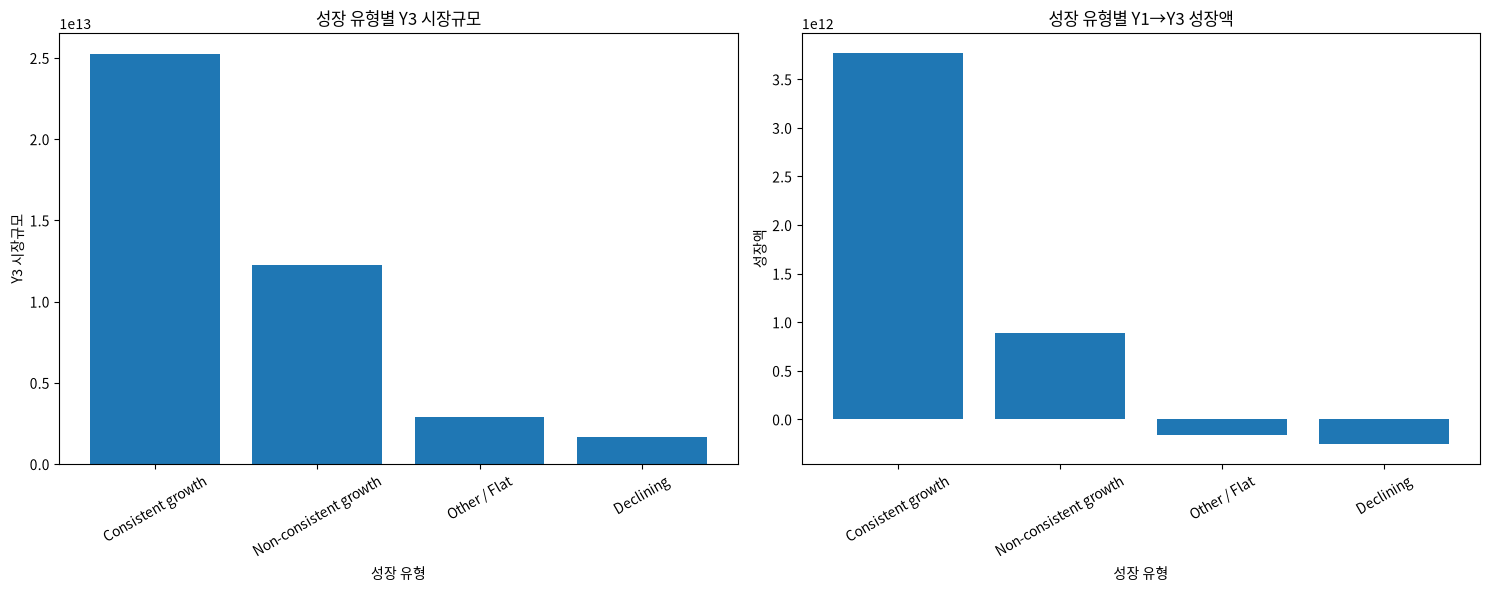

In [21]:
import matplotlib.pyplot as plt

plot_df = type_market_df.copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# 시장규모
axes[0].bar(
    plot_df["growth_type"],
    plot_df["y3_market_size"]
)

axes[0].set_title("성장 유형별 Y3 시장규모")
axes[0].set_xlabel("성장 유형")
axes[0].set_ylabel("Y3 시장규모")
axes[0].tick_params(axis="x", rotation=30)

# 성장액
axes[1].bar(
    plot_df["growth_type"],
    plot_df["total_growth_amount"]
)

axes[1].set_title("성장 유형별 Y1→Y3 성장액")
axes[1].set_xlabel("성장 유형")
axes[1].set_ylabel("성장액")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

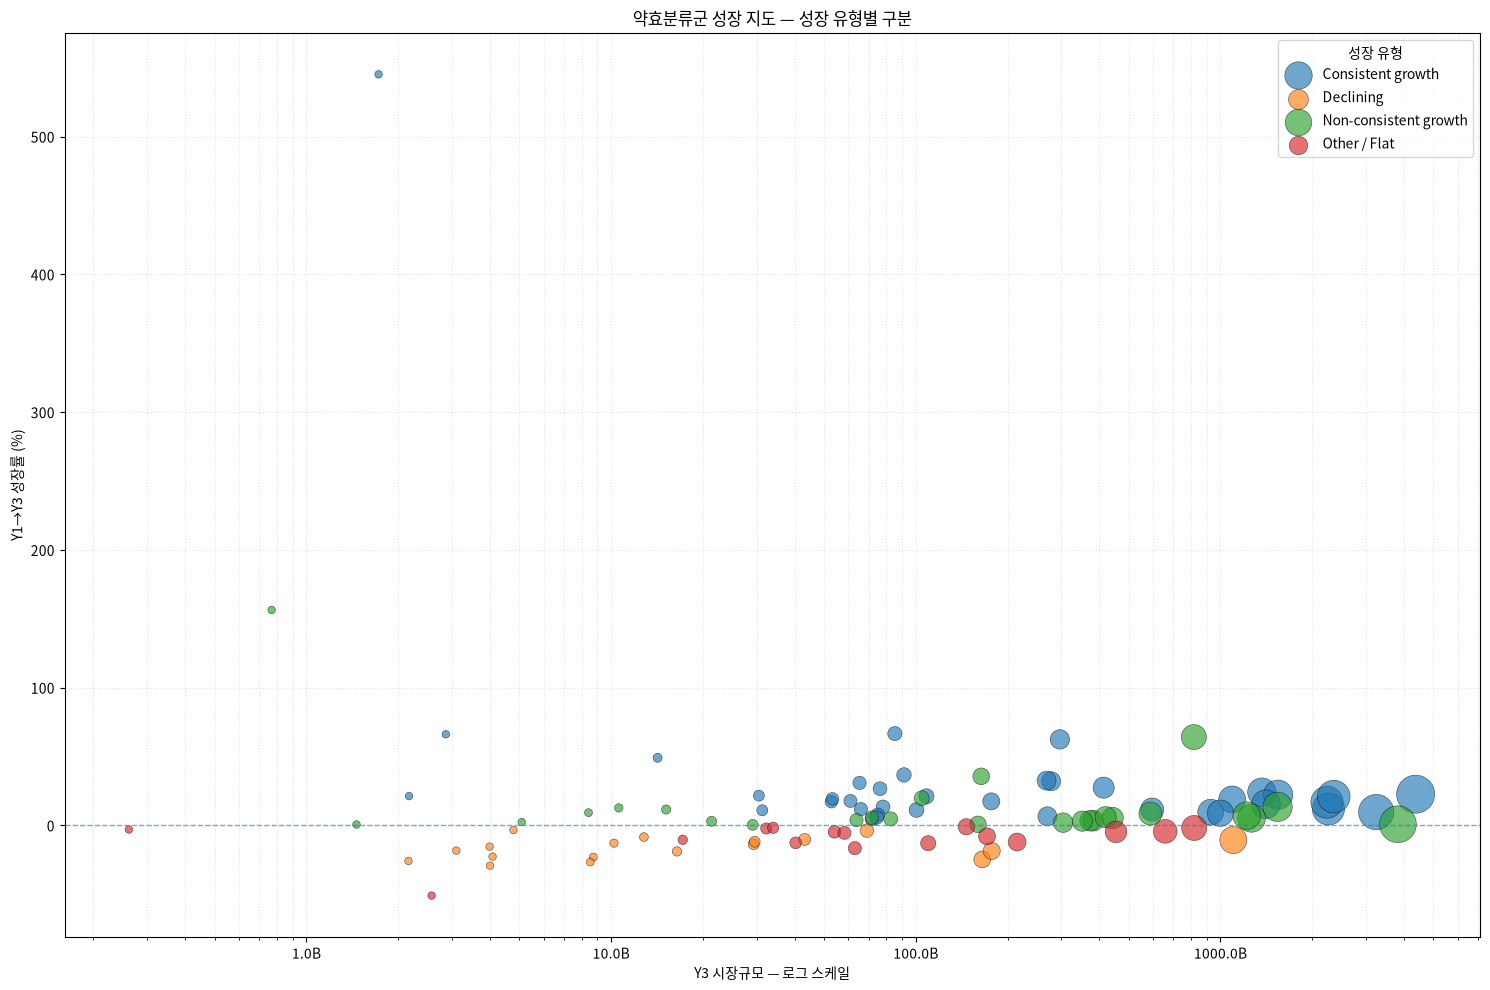

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

scatter_df = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    growth_type,
    amt_y3,
    amt_y1,
    amt_growth,
    amt_growth_rate
FROM growth_classified

WHERE
    amt_y3 > 0
    AND isfinite(amt_growth_rate)
""").df()

scatter_df["point_size"] = (
    np.sqrt(np.maximum(scatter_df["amt_y3"], 0))
    / np.sqrt(scatter_df["amt_y3"].median())
    * 100
).clip(30, 900)

fig, ax = plt.subplots(figsize=(15, 10))

growth_types = [
    "Consistent growth",
    "Declining",
    "Non-consistent growth",
    "Other / Flat"
]

for growth_type in growth_types:
    sub = scatter_df[
        scatter_df["growth_type"] == growth_type
    ]

    ax.scatter(
        sub["amt_y3"],
        sub["amt_growth_rate"],
        s=sub["point_size"],
        alpha=0.65,
        label=growth_type,
        edgecolors="black",
        linewidths=0.4
    )

ax.set_xscale("log")

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1e9:.1f}B")
)

ax.set_title("약효분류군 성장 지도 — 성장 유형별 구분")
ax.set_xlabel("Y3 시장규모 — 로그 스케일")
ax.set_ylabel("Y1→Y3 성장률 (%)")

ax.grid(
    True,
    which="both",
    linestyle=":",
    alpha=0.35
)

ax.legend(title="성장 유형")

plt.tight_layout()
plt.show()

In [27]:
# 성장률 대신 CAGR 사용

scatter_df["cagr_pct"] = (
    (
        scatter_df["amt_y3"] / scatter_df["amt_y1"]
    ) ** (1 / 2)
    - 1
) * 100

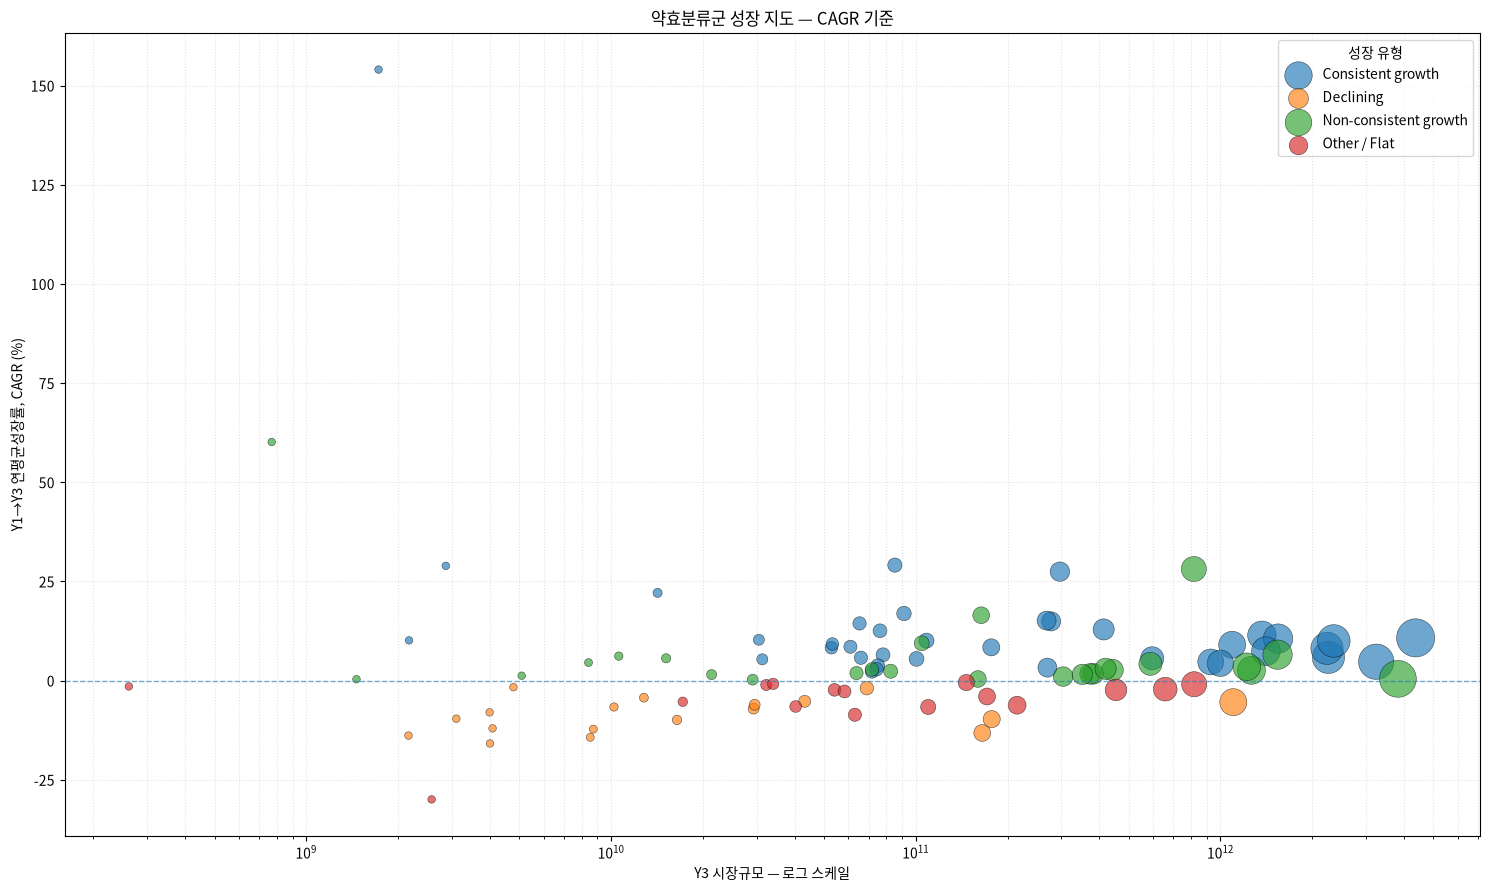

In [28]:
fig, ax = plt.subplots(figsize=(15, 9))

for growth_type in [
    "Consistent growth",
    "Declining",
    "Non-consistent growth",
    "Other / Flat"
]:
    sub = scatter_df[
        scatter_df["growth_type"] == growth_type
    ]

    ax.scatter(
        sub["amt_y3"],
        sub["cagr_pct"],
        s=sub["point_size"],
        alpha=0.65,
        label=growth_type,
        edgecolors="black",
        linewidths=0.4
    )

ax.set_xscale("log")
ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)

ax.set_title("약효분류군 성장 지도 — CAGR 기준")
ax.set_xlabel("Y3 시장규모 — 로그 스케일")
ax.set_ylabel("Y1→Y3 연평균성장률, CAGR (%)")

ax.grid(
    True,
    which="both",
    linestyle=":",
    alpha=0.35
)

ax.legend(title="성장 유형")

plt.tight_layout()
plt.show()

In [ ]:
extreme_growth_df = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,

    y1,
    y2,
    y3,

    amt_y1,
    amt_y2,
    amt_y3,

    amt_growth,
    amt_growth_rate,

    qty_y1,
    qty_y2,
    qty_y3,
    qty_growth_rate,

    growth_type

FROM growth_classified

WHERE
    amt_growth_rate > 100

ORDER BY
    amt_growth_rate DESC
""").df()

extreme_growth_df

,meftDivNo,meftDivNoNm,y1,y2,y3,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_rate,qty_y1,qty_y2,qty_y3,qty_growth_rate,growth_type
0,116,진훈제,2020,2021,2022,267263352.0,513535902.0,1.724557e+09,1.457294e+09,545.265045,7062988.0,13295644.0,44634610.0,531.950812,Consistent growth
1,729,기타의 진단용약,2020,2021,2022,299847652.0,293755548.0,7.688820e+08,4.690344e+08,156.424236,128696.0,124715.0,288456.0,124.137502,Non-consistent growth


## report summary

* 필수지표
* 시장점유율

In [37]:
nec_summary_df = con.execute("""
SELECT
    SUM(amt_y1) AS total_amt_y1,
    SUM(amt_y2) AS total_amt_y2,
    SUM(amt_y3) AS total_amt_y3,

    CASE
        WHEN SUM(amt_y1) > 0
        THEN (SUM(amt_y3) - SUM(amt_y1))
             / SUM(amt_y1) * 100.0
        ELSE NULL
    END AS total_cum_growth_pct,

    CASE
        WHEN SUM(amt_y1) > 0
         AND SUM(amt_y3) > 0
         AND MAX(y3) > MAX(y1)
        THEN (
            POWER(
                SUM(amt_y3) / SUM(amt_y1),
                1.0 / CAST(MAX(y3) - MAX(y1) AS DOUBLE)
            ) - 1
        ) * 100.0
        ELSE NULL
    END AS total_cagr_pct,

    SUM(amt_y3) - SUM(amt_y1) AS total_growth_amt
FROM growth_base;
""").df()

nec_summary_df.T

,0
total_amt_y1,3.784598e+13
total_amt_y2,4.119464e+13
total_amt_y3,4.208913e+13
total_cum_growth_pct,1.121163e+01
total_cagr_pct,5.456926e+00
total_growth_amt,4.243152e+12


In [4]:
con.execute("select * from growth_base limit 1").df()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,qty_y1,qty_y2,qty_y3,y1,y2,y3,amt_growth,amt_growth_rate,amt_growth_cagr,amt_consistent,qty_growth,qty_growth_rate,qty_consistent
0,713,용해제,4.964744e+09,5.431558e+09,5.086770e+09,17426463.0,18732413.0,17548891.0,2020,2021,2022,122026158.0,2.457854,1.221467,False,122428.0,0.702541,False


In [3]:
con.execute("select * from growth_classified limit 1").df()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,qty_y1,qty_y2,qty_y3,y1,y2,...,amt_growth,amt_growth_rate,amt_growth_cagr,amt_consistent,qty_growth,qty_growth_rate,qty_consistent,growth_type,is_consistent,is_declining
0,439,기타의 조직세포의 치료 및 진단,6.879718e+11,7.114710e+11,6.584701e+11,1866177.0,2028788.0,1778369.0,2020,2021,...,-2.950169e+10,-4.288212,-2.167598,False,-87808.0,-4.705234,False,Other / Flat,False,False


In [5]:
mkt_size_df = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_rate as amt_cum_growth_rate, 
    amt_growth_cagr,
    amt_y3 / SUM(amt_y3) OVER () * 100.0 AS y3_market_share_pct,
    growth_type
FROM growth_classified
WHERE amt_y3 > 0 
ORDER BY amt_y3 DESC
LIMIT 20;
""").df()

print(mkt_size_df.columns)
mkt_size_df.head()

Index(['meftDivNo', 'meftDivNoNm', 'amt_y1', 'amt_y2', 'amt_y3', 'amt_growth',
       'amt_cum_growth_rate', 'amt_growth_cagr', 'y3_market_share_pct',
       'growth_type'],
      dtype='str')


,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_cum_growth_rate,amt_growth_cagr,y3_market_share_pct,growth_type
0,218,동맥경화용제,3.562780e+12,4.099093e+12,4.370894e+12,8.081140e+11,22.682116,10.761959,10.384852,Consistent growth
1,421,항악성종양제,3.789804e+12,4.229958e+12,3.822577e+12,3.277274e+10,0.864761,0.431450,9.082099,Non-consistent growth
2,214,혈압강하제,2.957579e+12,3.175095e+12,3.244751e+12,2.871725e+11,9.709718,4.742407,7.709237,Consistent growth
3,232,소화성궤양용제,1.946299e+12,2.207121e+12,2.354223e+12,4.079245e+11,20.958988,9.981357,5.593422,Consistent growth
4,119,기타의 중추신경용약,2.017405e+12,2.205743e+12,2.260376e+12,2.429714e+11,12.043757,5.850724,5.370451,Consistent growth


In [33]:
mkt_growth_rate_df = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_rate as amt_cum_growth_rate, 
    amt_growth_cagr,
    amt_growth / SUM(amt_growth) OVER () * 100.0 AS amt_growth_share_pct,
    rank() OVER (order by amt_growth desc)  AS amt_growth_rank,
    amt_y1 / SUM(amt_y1) OVER () * 100.0 AS amt_y1_share_pct,
    rank() OVER (order by amt_y1 desc)  AS amt_y1_rank,
    amt_y3 / SUM(amt_y3) OVER () * 100.0 AS amt_y3_share_pct,
    rank() OVER (order by amt_y3 desc)  AS amt_y3_rank,
    growth_type
FROM growth_classified
WHERE amt_y1 > 0
  AND amt_y3 > 0
  AND amt_growth_cagr IS NOT NULL
ORDER BY amt_growth_cagr DESC
LIMIT 20;
""").df()

mkt_growth_rate_df.head()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_cum_growth_rate,amt_growth_cagr,amt_growth_share_pct,amt_growth_rank,amt_y1_share_pct,amt_y1_rank,amt_y3_share_pct,amt_y3_rank,growth_type
0,116,진훈제,2.672634e+08,5.135359e+08,1.724557e+09,1.457294e+09,545.265045,154.020677,0.034345,54,0.000706,98,0.004097,95,Consistent growth
1,729,기타의 진단용약,2.998477e+08,2.937555e+08,7.688820e+08,4.690344e+08,156.424236,60.132519,0.011054,60,0.000792,96,0.001827,97,Non-consistent growth
2,115,"각성제,흥분제",5.122360e+10,6.555406e+10,8.537278e+10,3.414918e+10,66.666877,29.099527,0.804807,23,0.135348,61,0.202838,47,Consistent growth
3,252,자궁수축제,1.725439e+09,2.195696e+09,2.867164e+09,1.141725e+09,66.170115,28.906988,0.026907,57,0.004559,94,0.006812,91,Consistent growth
4,222,진해거담제,4.981714e+11,4.589437e+11,8.176372e+11,3.194658e+11,64.127694,28.112331,7.528974,4,1.316313,21,1.942633,18,Non-consistent growth


####  pause : 기저효과 점검

In [37]:
# small_market_df = con.execute("""
# WITH thresholds AS (
#     SELECT
#         quantile_cont(amt_y1, 0.20) AS y1_p20,
#         quantile_cont(amt_y3, 0.20) AS y3_p20,
#         quantile_cont(amt_growth, 0.20) AS growth_amt_p20
#     FROM growth_classified
#     WHERE amt_y1 > 0
# )
# SELECT
#     g.*,

#     CASE WHEN g.amt_y1 <= t.y1_p20 THEN 1 ELSE 0 END
#     + CASE WHEN g.amt_y3 <= t.y3_p20 THEN 1 ELSE 0 END
#     + CASE WHEN g.amt_growth <= t.growth_amt_p20 THEN 1 ELSE 0 END
#     AS small_market_signal_count

# FROM growth_classified g
# CROSS JOIN thresholds t
# WHERE g.amt_y1 > 0;
# """).df()

    # amt_growth / SUM(amt_growth) OVER () * 100.0 AS amt_growth_share_pct,
    # rank() OVER (order by amt_growth desc)  AS amt_growth_rank,
    # amt_y1 / SUM(amt_y1) OVER () * 100.0 AS amt_y1_share_pct,
    # rank() OVER (order by amt_y1 desc)  AS amt_y1_rank,
    # amt_y3 / SUM(amt_y3) OVER () * 100.0 AS amt_y3_share_pct,
    # rank() OVER (order by amt_y3 desc)  AS amt_y3_rank,


sc_cols = ['amt_y1_rank', 'amt_y3_rank', 'amt_growth_rank']

# 조건에 해당하는 개수 계산 (0 ~ 3)
mkt_growth_rate_df['small_mkt_cnt'] = (mkt_growth_rate_df[sc_cols] > 75).sum(axis=1)

# 예: 2개 이상 만족하는 행만 필터링할 경우
small_market_df = mkt_growth_rate_df[mkt_growth_rate_df['small_mkt_cnt'] >= 2]

small_market_df.shape

(5, 16)

In [38]:
small_market_df.meftDivNo.values


<ArrowStringArray>
['116', '729', '252', '231', '256']
Length: 5, dtype: str

In [39]:
small_market_df

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_cum_growth_rate,amt_growth_cagr,amt_growth_share_pct,amt_growth_rank,amt_y1_share_pct,amt_y1_rank,amt_y3_share_pct,amt_y3_rank,growth_type,small_mkt_cnt
0,116,진훈제,2.672634e+08,5.135359e+08,1.724557e+09,1.457294e+09,545.265045,154.020677,0.034345,54,0.000706,98,0.004097,95,Consistent growth,2
1,729,기타의 진단용약,2.998477e+08,2.937555e+08,7.688820e+08,4.690344e+08,156.424236,60.132519,0.011054,60,0.000792,96,0.001827,97,Non-consistent growth,2
3,252,자궁수축제,1.725439e+09,2.195696e+09,2.867164e+09,1.141725e+09,66.170115,28.906988,0.026907,57,0.004559,94,0.006812,91,Consistent growth,2
6,231,치과구강용약,9.528638e+09,9.575488e+09,1.420576e+10,4.677125e+09,49.084926,22.100338,0.110228,46,0.025177,82,0.033752,78,Consistent growth,2
18,256,치질용제,1.789785e+09,2.019276e+09,2.170964e+09,3.811795e+08,21.297505,10.135147,0.008983,61,0.004729,93,0.005158,93,Consistent growth,2


### back

In [20]:
growth_type_df = con.execute("""SELECT
    growth_type,
    COUNT(*) AS group_count,
    SUM(amt_y3) AS total_amt_y3,
    SUM(amt_growth) AS total_growth_amt,
    AVG(amt_growth_cagr) AS avg_cagr_pct
FROM growth_classified
GROUP BY growth_type
ORDER BY total_amt_y3 DESC;""")

growth_type_df

In [44]:
growth_type_df = con.execute("""
SELECT
    growth_type,
    COUNT(*) AS group_count,
    SUM(amt_y3) AS total_amt_y3,
    SUM(amt_growth) AS total_growth_amt,
    AVG(amt_growth_cagr) AS avg_cagr_pct
FROM growth_classified
GROUP BY growth_type
ORDER BY total_amt_y3 DESC;
""").df()
growth_type_df


,growth_type,group_count,total_amt_y3,total_growth_amt,avg_cagr_pct
0,Consistent growth,38,2.525207e+13,3.771875e+12,14.236091
1,Non-consistent growth,26,1.226580e+13,8.890995e+11,6.533675
2,Other / Flat,16,2.876992e+12,-1.591986e+11,-5.116806
3,Declining,18,1.694266e+12,-2.586235e+11,-8.737210


,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,qty_y1,qty_y2,qty_y3,y1,y2,...,amt_growth_cagr,amt_consistent,qty_growth,qty_growth_rate,qty_consistent,growth_type,is_consistent,is_declining,log_amt_y3,amt_growth_abs
0,331,혈액대용제,3.698297e+11,3.842614e+11,3.825210e+11,348045890.0,357227667.0,347720657.0,2020,2021,...,1.701361,False,-325233.0,-0.093445,False,Non-consistent growth,False,False,11.582655,12691.326363
1,321,칼슘제,6.023592e+10,7.155924e+10,7.629462e+10,781274790.0,920430908.0,962824743.0,2020,2021,...,12.543174,True,181549953.0,23.237657,True,Consistent growth,True,False,10.882494,16058.692213
2,323,당류제,4.808457e+10,4.707821e+10,4.318467e+10,38158673.0,37653929.0,34367552.0,2020,2021,...,-5.231954,False,-3791121.0,-9.935149,False,Declining,False,True,10.635330,4899.901658
3,249,기타의 호르몬제(항호르몬제를 포함),3.610481e+11,3.876257e+11,3.732086e+11,17491426.0,18585012.0,17929596.0,2020,2021,...,1.670102,False,438170.0,2.505056,False,Non-consistent growth,False,False,11.571952,12160.448560
4,124,진경제,6.858678e+10,7.123724e+10,7.180274e+10,530215780.0,551492914.0,572761948.0,2020,2021,...,2.317591,True,42546168.0,8.024312,True,Consistent growth,True,False,10.856141,3215.961791


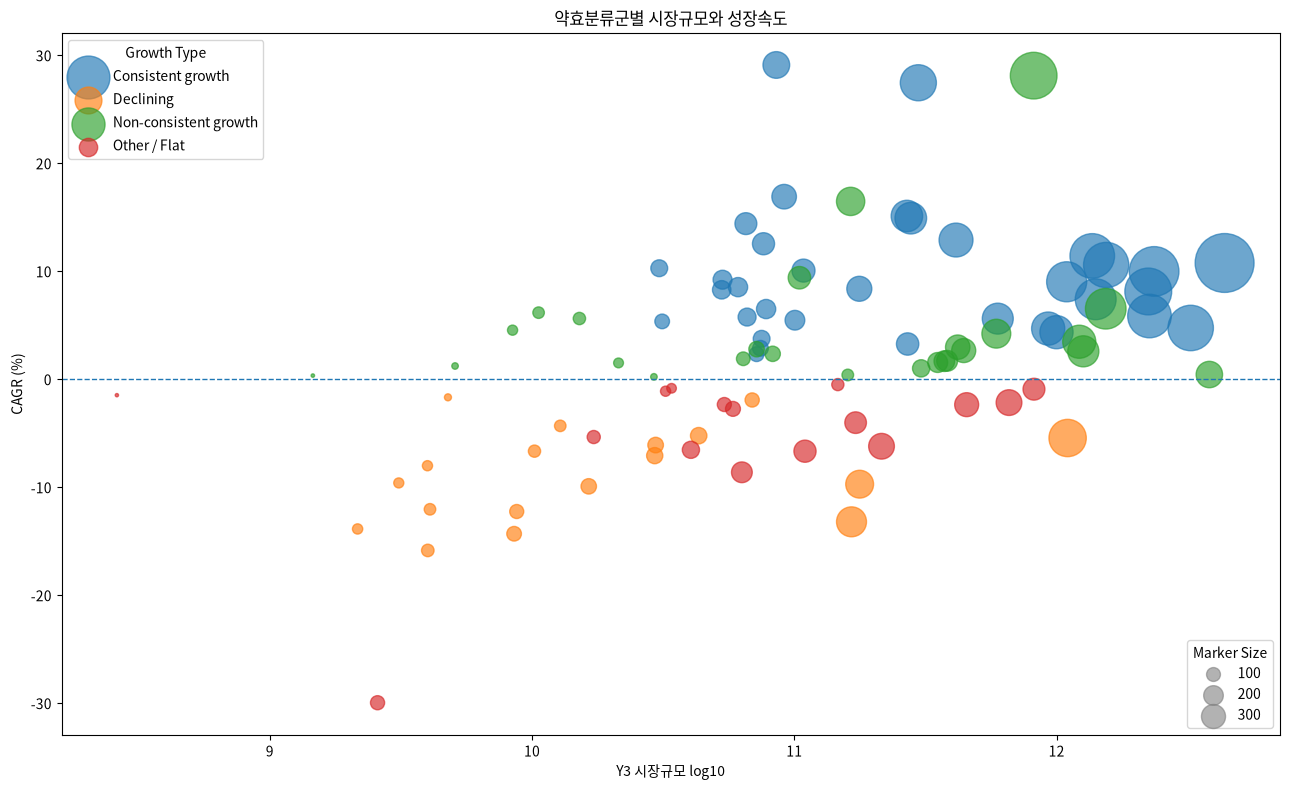

In [51]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = con.execute("""
select 
*,
log(amt_y3) as log_amt_y3,
abs(amt_growth)/1e6 as amt_growth_abs
from growth_classified
where amt_y3 > 0 and amt_growth_cagr is not null
and meftDivNo not in ('116', '729', '252', '231', '256')
""").df()

display(plot_df.head())


fig, ax = plt.subplots(figsize=(13, 8))

scatter_obj = None
for growth_type, group in plot_df.groupby("growth_type"):
    scatter_obj = ax.scatter(
        group["log_amt_y3"],
        group["amt_growth_cagr"],
        s=np.sqrt(group["amt_growth_abs"].clip(lower=1)) * 2,
        alpha=0.65,
        label=growth_type
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Y3 시장규모 log10")
ax.set_ylabel("CAGR (%)")
ax.set_title("약효분류군별 시장규모와 성장속도")

# 첫 번째 Legend (growth_type)
leg1 = ax.legend(title="Growth Type", loc="upper left")
# Size Legend 자동으로 추출 및 추가
handles, labels = scatter_obj.legend_elements(prop="sizes", num=4, alpha=0.6, color='grey')
# 각 Size 핸들의 마커 크기를 동일하게 고정 (예: 50)
for handle in handles:
    handle._sizes = [50]
leg2 = ax.legend(handles, labels, title="Marker Size", loc="lower right")

ax.add_artist(leg1)

# ax.legend()
plt.tight_layout()
plt.show()

### sensitivity data check

In [ ]:
sensitivity_df.columns 

Index(['meftDivNo', 'meftDivNoNm', 'amt_y1', 'amt_y2', 'amt_y3', 'qty_y1',
       'qty_y2', 'qty_y3', 'y1', 'y2', 'y3', 'amt_growth', 'amt_growth_rate',
       'amt_growth_cagr', 'amt_consistent', 'qty_growth', 'qty_growth_rate',
       'qty_consistent', 'growth_type', 'is_consistent', 'is_declining',
       'largest_rank', 'rapid_rank', 'consistent_rank', 'declining_rank', 'n',
       'is_largest_topn', 'is_rapid_topn', 'is_consistent_topn',
       'is_declining_topn', 'condition_count', 'largest_rapid_consistent',
       'largest_rapid_declining', 'largest_consistent', 'largest_declining',
       'rapid_consistent', 'rapid_declining'],
      dtype='str')

In [71]:
top_n_sensitivity_df = con.execute("""
SELECT
    n,
    COUNT(*) AS total_groups,
    SUM(CASE WHEN condition_count >= 2 THEN 1 ELSE 0 END)
        AS groups_2_conditions,
    SUM(CASE WHEN condition_count >= 3 THEN 1 ELSE 0 END)
        AS groups_3_conditions,
    SUM(CASE WHEN is_declining_topn THEN 1 ELSE 0 END)
        AS declining_groups
FROM growth_sensitivity
GROUP BY 1
ORDER BY 1;
""").df()

top_n_sensitivity_df

,n,total_groups,groups_2_conditions,groups_3_conditions,declining_groups
0,10,98,7.0,0.0,10.0
1,15,98,15.0,1.0,15.0
2,20,98,21.0,3.0,18.0
3,30,98,30.0,9.0,18.0


In [3]:
con.execute("""
SELECT
    n,
    COUNT(*) AS rows,
    COUNT(DISTINCT meftDivNo) AS groups
FROM growth_sensitivity
GROUP BY 1
ORDER BY 1;
""").df()

,n,rows,groups
0,10,98,98
1,15,98,98
2,20,98,98
3,30,98,98


In [4]:
con.execute("""
SELECT
    meftDivNo,
    COUNT(*) AS n
FROM growth_sensitivity
GROUP BY meftDivNo
HAVING COUNT(*) > 1
ORDER BY n DESC
LIMIT 10;""").df()

,meftDivNo,n
0,728,4
1,611,4
2,332,4
3,265,4
4,721,4
5,341,4
6,395,4
7,391,4
8,245,4
9,239,4


### market position table

In [106]:
# Top 10에서만 나타나는 후보: 순위 민감도가 높음

# Top 10·15·20·30에 반복 등장하는 후보: 상대적으로 안정적

# 규모 Top에는 있지만 성장 Top에는 없는 후보: 성숙시장

# 성장 Top에는 있지만 규모 Top에는 없는 후보: 초기 성장시장

# Declining Top에 반복 등장하는 후보: 구조적 감소 가능성 검토 대상
con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y3,
    amt_growth,
    amt_growth_cagr,
    largest_rank,
    rapid_rank,
    consistent_rank,
    declining_rank
FROM growth_sensitivity
WHERE 
 n = 10 
 and (largest_rank <= 15
   AND rapid_rank <= 15 )
ORDER BY
    LEAST(
        COALESCE(largest_rank, 999999),
        COALESCE(rapid_rank, 999999),
        COALESCE(consistent_rank, 999999),
        COALESCE(declining_rank, 999999)
    ),
    amt_y3 DESC;
""").df()

,meftDivNo,meftDivNoNm,amt_y3,amt_growth,amt_growth_cagr,largest_rank,rapid_rank,consistent_rank,declining_rank
0,131,안과용제,1.367577e+12,2.658998e+11,11.416295,10,15,12,66


In [100]:
# 규모 Top에는 있지만 성장 Top에는 없는 후보
con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_cagr,
    largest_rank,
    rapid_rank,
    consistent_rank,
    growth_type
FROM growth_sensitivity
WHERE n = 10 
and  largest_rank <= 10
  AND (rapid_rank > 10 OR rapid_rank IS NULL)
ORDER BY
    largest_rank;""").df()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_cagr,largest_rank,rapid_rank,consistent_rank,growth_type
0,218,동맥경화용제,3.562780e+12,4.099093e+12,4.370894e+12,8.081140e+11,10.761959,1,16,13,Consistent growth
1,421,항악성종양제,3.789804e+12,4.229958e+12,3.822577e+12,3.277274e+10,0.431450,2,61,23,Non-consistent growth
2,214,혈압강하제,2.957579e+12,3.175095e+12,3.244751e+12,2.871725e+11,4.742407,3,39,32,Consistent growth
3,232,소화성궤양용제,1.946299e+12,2.207121e+12,2.354223e+12,4.079245e+11,9.981357,4,21,18,Consistent growth
4,119,기타의 중추신경용약,2.017405e+12,2.205743e+12,2.260376e+12,2.429714e+11,5.850724,5,33,27,Consistent growth
5,396,당뇨병용제,1.912711e+12,2.113081e+12,2.236066e+12,3.233549e+11,8.122883,6,28,24,Consistent growth
6,114,해열·진통·소염제,1.263721e+12,1.358778e+12,1.545192e+12,2.814705e+11,10.577189,7,17,14,Consistent growth
7,618,"주로 그람양성,음성균에 작용하는 것",1.356621e+12,1.347496e+12,1.539382e+12,1.827614e+11,6.523147,8,30,5,Non-consistent growth
8,399,따로 분류되지 않는 대사성 의약품,1.221638e+12,1.355124e+12,1.409214e+12,1.875758e+11,7.403187,9,29,25,Consistent growth
9,131,안과용제,1.101677e+12,1.228404e+12,1.367577e+12,2.658998e+11,11.416295,10,15,12,Consistent growth


In [103]:
# 성장 Top에는 있지만 규모 Top에는 없는 후보보
con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_cagr,
    largest_rank,
    rapid_rank,
    consistent_rank,
    growth_type
FROM growth_sensitivity
WHERE n = 10 
and rapid_rank <= 10
  AND (largest_rank > 20 OR largest_rank IS NULL)
ORDER BY
    rapid_rank;""").df()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_cagr,largest_rank,rapid_rank,consistent_rank,growth_type
0,116,진훈제,2.672634e+08,5.135359e+08,1.724557e+09,1.457294e+09,154.020677,95,1,1,Consistent growth
1,729,기타의 진단용약,2.998477e+08,2.937555e+08,7.688820e+08,4.690344e+08,60.132519,97,2,1,Non-consistent growth
2,115,"각성제,흥분제",5.122360e+10,6.555406e+10,8.537278e+10,3.414918e+10,29.099527,47,3,2,Consistent growth
3,252,자궁수축제,1.725439e+09,2.195696e+09,2.867164e+09,1.141725e+09,28.906988,91,4,3,Consistent growth
4,241,뇌하수체호르몬제,1.828763e+11,2.324809e+11,2.970644e+11,1.141881e+11,27.451997,30,6,4,Consistent growth
5,231,치과구강용약,9.528638e+09,9.575488e+09,1.420576e+10,4.677125e+09,22.100338,78,7,5,Consistent growth
6,237,정장제,6.691175e+10,7.351294e+10,9.144217e+10,2.453043e+10,16.902040,46,8,6,Consistent growth
7,619,기타의 항생물질 제제(복합항생물질제제를 포함),1.208513e+11,1.073000e+11,1.639227e+11,4.307143e+10,16.464596,39,9,3,Non-consistent growth
8,141,항히스타민제,2.027443e+11,2.073055e+11,2.686600e+11,6.591563e+10,15.113726,33,10,7,Consistent growth


In [109]:
# Declining Top에는 있고 규모 Top 후보보
con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y1,
    amt_y2,
    amt_y3,
    amt_growth,
    amt_growth_cagr,
    largest_rank,
    declining_rank,
    growth_type
FROM growth_sensitivity
WHERE n=10
and  declining_rank <= 10
  AND largest_rank <= 25
ORDER BY
    largest_rank;""").df()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_cagr,largest_rank,declining_rank,growth_type
0,634,혈액제제류,4.762240e+11,4.905657e+11,4.540208e+11,-2.220311e+10,-2.358987,22,9,Other / Flat


### last

In [1]:
con.execute("""
CREATE OR REPLACE VIEW market_position AS

WITH group_level AS (

    SELECT
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm,

        MAX(amt_y1) AS amt_y1,
        MAX(amt_y2) AS amt_y2,
        MAX(amt_y3) AS amt_y3,

        MAX(amt_growth) AS amt_growth,
        MAX(amt_growth_rate) AS amt_cum_growth_rate,
        MAX(amt_growth_cagr) AS amt_growth_cagr,

        MIN(largest_rank) AS largest_rank,
        MIN(rapid_rank) AS rapid_rank,
        MIN(consistent_rank) AS consistent_rank,
        MIN(declining_rank) AS declining_rank,

        MAX(growth_type) AS growth_type

    FROM growth_sensitivity
    GROUP BY meftDivNo
)

SELECT
    *,

    CASE

        WHEN largest_rank <= 20
         AND rapid_rank <= 20
         AND consistent_rank <= 20
            THEN '규모·성장·지속성 상위(핵심성장)'

        WHEN largest_rank <40
            AND amt_cum_growth_rate > 0
            THEN '중대형 성장시장(지속성 점검)'
                    
        WHEN largest_rank > 40 
            AND rapid_rank <= 20 
            AND amt_cum_growth_rate > 0
                THEN '이머징 성장시장(소형·고성장)'
        WHEN declining_rank <= 20
            THEN 
            CASE 
                WHEN largest_rank < 30 
                AND amt_cum_growth_rate < 0 
                    THEN '중대형 감소시장'
                
                ELSE '역성장시장'
            END

        ELSE '기타'

    END AS market_position

FROM group_level;""")

NameError: name 'con' is not defined

In [49]:
con.execute("""SELECT
    market_position,
    COUNT(*) AS group_count,
    SUM(amt_y3) AS total_y3_amt,
    SUM(amt_growth) AS total_growth_amt,
    AVG(amt_growth_cagr) AS avg_cagr_pct
FROM market_position
GROUP BY market_position
ORDER BY total_y3_amt DESC;""").df()

,market_position,group_count,total_y3_amt,total_growth_amt,avg_cagr_pct
0,대형·성장 중위,8,1.473300e+13,1.866747e+12,7.156688
1,규모·성장·지속성 상위,4,8.101300e+12,1.674950e+12,15.216943
2,기타,26,6.211326e+12,4.542799e+11,4.661292
3,역성장 상위,34,5.550610e+12,-1.859958e+11,-6.672509
4,중대형·지속성장 상위,11,3.980057e+12,5.082293e+11,9.234415
5,중대형·고역성장,4,3.033710e+12,-1.976767e+11,-2.724982
6,소형·고성장,11,4.791262e+11,1.226181e+11,33.507282


In [50]:
## validity check
con.execute("""SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT meftDivNo) AS distinct_groups
FROM market_position;""").df()

,total_rows,distinct_groups
0,98,98


In [51]:
con.execute("""SELECT
    market_position,
    meftDivNo,
    meftDivNoNm,
    amt_y1,
    amt_y3,
    amt_growth,
    amt_growth_cagr,
    largest_rank,
    rapid_rank,
    consistent_rank,
    declining_rank,
    growth_type
FROM market_position
WHERE market_position <> '기타'
ORDER BY
    market_position,
    amt_y3 DESC;""").df()

,market_position,meftDivNo,meftDivNoNm,amt_y1,amt_y3,amt_growth,amt_growth_cagr,largest_rank,rapid_rank,consistent_rank,declining_rank,growth_type
0,규모·성장·지속성 상위,218,동맥경화용제,3.562780e+12,4.370894e+12,8.081140e+11,10.761959,1,16,13,65,Consistent growth
1,규모·성장·지속성 상위,114,해열·진통·소염제,1.263721e+12,1.545192e+12,2.814705e+11,10.577189,7,17,14,64,Consistent growth
2,규모·성장·지속성 상위,131,안과용제,1.101677e+12,1.367577e+12,2.658998e+11,11.416295,10,15,12,66,Consistent growth
3,규모·성장·지속성 상위,222,진해거담제,4.981714e+11,8.176372e+11,3.194658e+11,28.112331,18,5,2,76,Non-consistent growth
4,대형·성장 중위,214,혈압강하제,2.957579e+12,3.244751e+12,2.871725e+11,4.742407,3,39,32,42,Consistent growth
...,...,...,...,...,...,...,...,...,...,...,...,...
67,중대형·지속성장 상위,325,단백아미노산제제,3.413585e+11,3.519998e+11,1.064134e+10,1.546713,28,57,19,24,Non-consistent growth
68,중대형·지속성장 상위,241,뇌하수체호르몬제,1.828763e+11,2.970644e+11,1.141881e+11,27.451997,30,6,4,75,Consistent growth
69,중대형·지속성장 상위,229,기타의 호흡기관용약,2.105092e+11,2.779748e+11,6.746551e+10,14.912451,31,11,8,70,Consistent growth
70,중대형·지속성장 상위,141,항히스타민제,2.027443e+11,2.686600e+11,6.591563e+10,15.113726,33,10,7,71,Consistent growth


### PLOT CLUSTERS

In [59]:
plot_df = con.execute("""
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_y3,
    amt_cum_growth_rate,
    amt_growth,
    market_position
FROM market_position
WHERE amt_y3 > 0
  AND amt_growth_cagr IS NOT NULL
  AND market_position IS NOT NULL
""").df()

print(plot_df.shape)
plot_df.head()

(98, 6)


,meftDivNo,meftDivNoNm,amt_y3,amt_cum_growth_rate,amt_growth,market_position
0,323,당류제,4.318467e+10,-10.190174,-4.899902e+09,역성장 상위
1,713,용해제,5.086770e+09,2.457854,1.220262e+08,기타
2,249,기타의 호르몬제(항호르몬제를 포함),3.732086e+11,3.368096,1.216045e+10,중대형·지속성장 상위
3,331,혈액대용제,3.825210e+11,3.431668,1.269133e+10,중대형·지속성장 상위
4,124,진경제,7.180274e+10,4.688894,3.215962e+09,기타


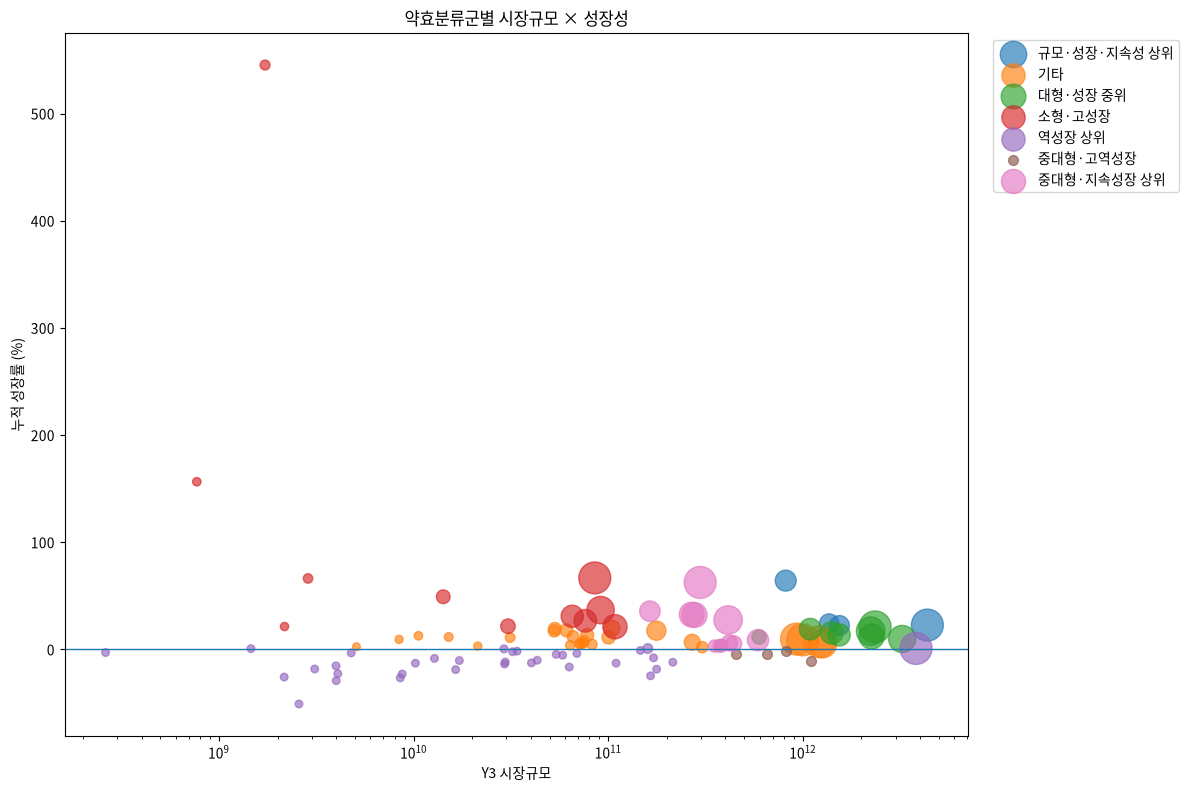

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

for group, df in plot_df.groupby("market_position"):

    growth = df["amt_growth"].clip(lower=0)

    if growth.max() > 0:
        size = growth / growth.max() * 500 + 30
    else:
        size = 50

    ax.scatter(
        df["amt_y3"],
        df["amt_cum_growth_rate"],
        s=size,
        alpha=0.65,
        label=group
    )

ax.set_xscale("log")

ax.set_xlabel("Y3 시장규모")
ax.set_ylabel("누적 성장률 (%)")
ax.set_title("약효분류군별 시장규모 × 성장성")

ax.axhline(0, linewidth=1)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [64]:
group_summary = con.execute("""
SELECT
    market_position,

    COUNT(*) AS group_count,

    SUM(amt_y3) AS y3_market_size,

    SUM(amt_growth) AS growth_amount,

    SUM(amt_growth) / 1e8 AS growth_amount_100m,

    SUM(amt_y3)
        / SUM(SUM(amt_y3)) OVER ()
        * 100.0 AS market_share_pct

FROM market_position

GROUP BY market_position

ORDER BY y3_market_size DESC
""").df()

group_summary

,market_position,group_count,y3_market_size,growth_amount,growth_amount_100m,market_share_pct
0,대형·성장 중위,8,1.473300e+13,1.866747e+12,18667.471494,35.004294
1,규모·성장·지속성 상위,4,8.101300e+12,1.674950e+12,16749.500943,19.247962
2,기타,26,6.211326e+12,4.542799e+11,4542.799401,14.757553
3,역성장 상위,34,5.550610e+12,-1.859958e+11,-1859.957664,13.187752
4,중대형·지속성장 상위,11,3.980057e+12,5.082293e+11,5082.293461,9.456258
5,중대형·고역성장,4,3.033710e+12,-1.976767e+11,-1976.766640,7.207822
6,소형·고성장,11,4.791262e+11,1.226181e+11,1226.180508,1.138361


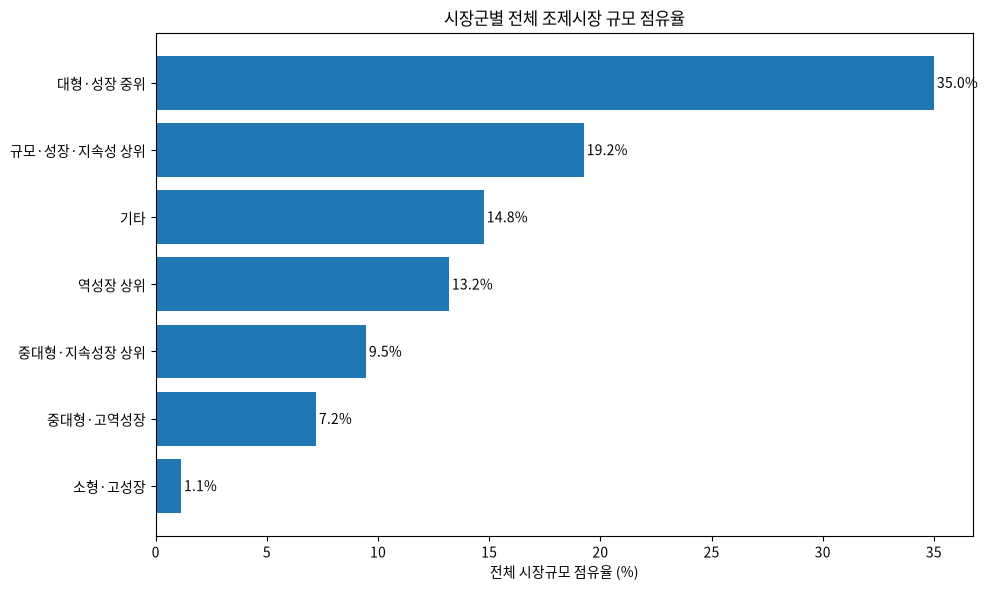

In [65]:
import matplotlib.pyplot as plt

bar_df = group_summary.sort_values(
    "market_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    bar_df["market_position"],
    bar_df["market_share_pct"]
)

ax.set_xlabel("전체 시장규모 점유율 (%)")
ax.set_ylabel("")
ax.set_title("시장군별 전체 조제시장 규모 점유율")

for i, v in enumerate(bar_df["market_share_pct"]):
    ax.text(
        v,
        i,
        f" {v:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
cluster_df_list = []

for idf_name in ['규모·성장 중위','규모·성장·지속성 상위',
                   '고역성장·중대형','중대형·지속성장 상위',
                   '역성장 상위','중소형·성장 상위']:
    cluster_df_list.append(
        con.execute(f"""
        SELECT
            meftDivNo,
            meftDivNoNm,
            amt_y3,
            amt_growth,
            amt_growth / 100000000.0 AS growth_amount_100m,
            amt_growth_cagr,
            largest_rank,
            rapid_rank,
            consistent_rank
        FROM market_position
        WHERE market_position = '{idf_name}'
        ORDER BY amt_y3 DESC
        LIMIT 10;
        """).df()
    ) 



In [45]:
cluster_df_list[0].head()

,meftDivNo,meftDivNoNm,amt_y3,amt_growth,growth_amount_100m,amt_growth_cagr,largest_rank,rapid_rank,consistent_rank
0,214,혈압강하제,3.244751e+12,2.871725e+11,2871.725418,4.742407,3,39,32
1,232,소화성궤양용제,2.354223e+12,4.079245e+11,4079.244970,9.981357,4,21,18
2,119,기타의 중추신경용약,2.260376e+12,2.429714e+11,2429.713525,5.850724,5,33,27
3,396,당뇨병용제,2.236066e+12,3.233549e+11,3233.549136,8.122883,6,28,24
4,618,"주로 그람양성,음성균에 작용하는 것",1.539382e+12,1.827614e+11,1827.613601,6.523147,8,30,5


## ref : top 10 - each sectors : largest, rapid, consistent

In [ ]:
# hightest segment

meft_year = con.execute("""
WITH yearly AS (
    SELECT
        LEFT(CAST(diagYm AS VARCHAR), 4) AS year,
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm,
        SUM(totUseQty) AS amt,
        SUM(msupUseAmt) AS qty
    FROM mefi_sick
    GROUP BY 1, 2
),

years AS (
    SELECT
        year,
        ROW_NUMBER() OVER (ORDER BY year) AS rn
    FROM (
        SELECT DISTINCT year
        FROM yearly
    )
),

annual AS (
    SELECT
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm,

        MAX(CASE WHEN year = (SELECT year FROM years WHERE rn = 1)
                 THEN amt END) AS amt_y1,

        MAX(CASE WHEN year = (SELECT year FROM years WHERE rn = 2)
                 THEN amt END) AS amt_y2,

        MAX(CASE WHEN year = (SELECT year FROM years WHERE rn = 3)
                 THEN amt END) AS amt_y3,

        MAX(CASE WHEN year = (SELECT year FROM years WHERE rn = 1)
                 THEN qty END) AS qty_y1,

        MAX(CASE WHEN year = (SELECT year FROM years WHERE rn = 2)
                 THEN qty END) AS qty_y2,

        MAX(CASE WHEN year = (SELECT year FROM years WHERE rn = 3)
                 THEN qty END) AS qty_y3

    FROM yearly

    WHERE year IN (
        SELECT year
        FROM years
        WHERE rn <= 3
    )

    GROUP BY meftDivNo
)

SELECT
    *,
    
    amt_y3 - amt_y1 AS amt_growth,

    100.0 * (
        amt_y3 / NULLIF(amt_y1, 0) - 1
    ) AS amt_growth_pct,

    qty_y3 - qty_y1 AS qty_growth,

    100.0 * (
        qty_y3 / NULLIF(qty_y1, 0) - 1
    ) AS qty_growth_pct,

    CASE
        WHEN amt_y1 < amt_y2
         AND amt_y2 < amt_y3
        THEN TRUE
        ELSE FALSE
    END AS amt_consistent,

    CASE
        WHEN qty_y1 < qty_y2
         AND qty_y2 < qty_y3
        THEN TRUE
        ELSE FALSE
    END AS qty_consistent

FROM annual

WHERE amt_y1 IS NOT NULL
  AND amt_y2 IS NOT NULL
  AND amt_y3 IS NOT NULL
  AND qty_y1 IS NOT NULL
  AND qty_y2 IS NOT NULL
  AND qty_y3 IS NOT NULL
""").fetchdf()

meft_year.head()

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,qty_y1,qty_y2,qty_y3,amt_growth,amt_growth_pct,qty_growth,qty_growth_pct,amt_consistent,qty_consistent
0,124,진경제,6.858678e+10,7.123724e+10,7.180274e+10,5.302158e+08,5.514929e+08,5.727619e+08,3.215962e+09,4.688894,42546168.0,8.024312,True,True
1,229,기타의 호흡기관용약,2.105092e+11,2.276276e+11,2.779748e+11,5.640582e+08,5.250216e+08,9.496405e+08,6.746551e+10,32.048715,385582288.0,68.358594,True,False
2,249,기타의 호르몬제(항호르몬제를 포함),3.610481e+11,3.876257e+11,3.732086e+11,1.749143e+07,1.858501e+07,1.792960e+07,1.216045e+10,3.368096,438170.0,2.505056,False,False
3,259,기타의 비뇨생식기관 및 항문용약,8.474317e+11,9.204000e+11,9.287435e+11,1.401930e+09,1.537340e+09,1.637078e+09,8.131182e+10,9.595088,235147350.0,16.773110,True,True
4,321,칼슘제,6.023592e+10,7.155924e+10,7.629462e+10,7.812748e+08,9.204309e+08,9.628247e+08,1.605869e+10,26.659659,181549953.0,23.237657,True,True


In [ ]:
# 금액기준

amt_largest = (
    meft_year
    .sort_values("amt_y3", ascending=False)
    .head(10)
    .copy()
)

amt_largest[
    ["meftDivNo", "meftDivNoNm", "amt_y3"]
]

,meftDivNo,meftDivNoNm,amt_y3
43,218,동맥경화용제,4.370894e+12
49,421,항악성종양제,3.822577e+12
74,214,혈압강하제,3.244751e+12
65,232,소화성궤양용제,2.354223e+12
25,119,기타의 중추신경용약,2.260376e+12
39,396,당뇨병용제,2.236066e+12
96,114,해열·진통·소염제,1.545192e+12
60,618,"주로 그람양성,음성균에 작용하는 것",1.539382e+12
93,399,따로 분류되지 않는 대사성 의약품,1.409214e+12
42,131,안과용제,1.367577e+12


In [6]:
amt_rapid = (
    meft_year
    .sort_values("amt_growth_pct", ascending=False)
    .head(10)
    .copy()
)

amt_rapid[
    ["meftDivNo", "meftDivNoNm", "amt_growth_pct"]
]

,meftDivNo,meftDivNoNm,amt_growth_pct
86,116,진훈제,545.265045
8,729,기타의 진단용약,156.424236
97,115,"각성제,흥분제",66.666877
90,252,자궁수축제,66.170115
64,222,진해거담제,64.127694
57,241,뇌하수체호르몬제,62.440115
56,231,치과구강용약,49.084926
89,237,정장제,36.660869
82,619,기타의 항생물질 제제(복합항생물질제제를 포함),35.640022
62,141,항히스타민제,32.511700


In [7]:
amt_consistent = (
    meft_year[
        meft_year["amt_consistent"]
    ]
    .sort_values("amt_growth_pct", ascending=False)
    .head(10)
    .copy()
)

amt_consistent[
    ["meftDivNo", "meftDivNoNm", "amt_growth_pct"]
]

,meftDivNo,meftDivNoNm,amt_growth_pct
86,116,진훈제,545.265045
97,115,"각성제,흥분제",66.666877
90,252,자궁수축제,66.170115
57,241,뇌하수체호르몬제,62.440115
56,231,치과구강용약,49.084926
89,237,정장제,36.660869
62,141,항히스타민제,32.511700
1,229,기타의 호흡기관용약,32.048715
51,614,"주로 그람양성균,리케치아,비루스에 작용하는 것",30.889501
29,149,기타의 알레르기용약,27.431156


In [12]:
# highest intersection

def get_intersection_top3( rapid, consistent, growth_col):
    
    # largest_codes = set(largest["meftDivNo"])
    rapid_codes = set(rapid["meftDivNo"])
    consistent_codes = set(consistent["meftDivNo"])

    intersection = (
        # largest_codes
        # & 
        rapid_codes
        & consistent_codes
    )

    result = (
        meft_year[
            meft_year["meftDivNo"].isin(intersection)
        ]
        .sort_values(growth_col, ascending=False)
        .head(3)
        .copy()
    )

    return result

In [13]:
amt_top3 = get_intersection_top3(
    # amt_largest,
    amt_rapid,
    amt_consistent,
    # "amt_growth_pct"
    "amt_y3"
)

amt_top3[
    [
        "meftDivNo",
        "meftDivNoNm",
        "amt_y1",
        "amt_y2",
        "amt_y3",
        "amt_growth",
        "amt_growth_pct"
    ]
]

,meftDivNo,meftDivNoNm,amt_y1,amt_y2,amt_y3,amt_growth,amt_growth_pct
57,241,뇌하수체호르몬제,1.828763e+11,2.324809e+11,2.970644e+11,1.141881e+11,62.440115
62,141,항히스타민제,2.027443e+11,2.073055e+11,2.686600e+11,6.591563e+10,32.511700
89,237,정장제,6.691175e+10,7.351294e+10,9.144217e+10,2.453043e+10,36.660869
